# 🧠 FakeShield — Advanced Fake News Detection System
**Version 3.0 | Domain-Specialised | Production-Grade**

---

## Architecture Overview

```
Raw Input (text + title + source)
         │
    ┌────▼────────────────────────────────────┐
    │  Stage 0: Preprocessing Pipeline        │
    │  • Boilerplate removal                  │
    │  • Doubled-title de-duplication         │
    │  • Meta-feature extraction              │
    │  • title [SEP] clean_text assembly      │
    └────┬────────────────────────────────────┘
         │
    ┌────▼──────────────────────────────────────────────────────────┐
    │  Domain Router                                                 │
    │  politifact → Model 1   │   gossipcop → Model 2               │
    └────┬──────────────────────────────────────┬────────────────────┘
         │                                      │
  ┌──────▼──────┐                        ┌──────▼──────┐
  │  PATH A     │                        │  PATH A     │
  │  Stack      │                        │  Stack      │
  │  ─────────  │                        │  ─────────  │
  │  TF-IDF     │                        │  TF-IDF     │
  │  word(1,3)  │                        │  word(1,3)  │
  │  char(3,5)  │                        │  char(3,5)  │
  │  + MetaFeat │                        │  + MetaFeat │
  │  ↓          │                        │  ↓          │
  │  LR + RF    │                        │  LR + RF    │
  │  + LinSVC   │                        │  + LinSVC   │
  │  ↓          │                        │  ↓          │
  │  Meta-LR    │                        │  Meta-LR    │
  │  + thresh   │                        │  + thresh   │
  └──────┬──────┘                        └──────┬──────┘
         │                                      │
  ┌──────▼──────┐                        ┌──────▼──────┐
  │  PATH B     │                        │  PATH B     │
  │  BERT       │                        │  BERT       │
  │  ─────────  │                        │  ─────────  │
  │  bert-base  │                        │  bert-base  │
  │  uncased    │                        │  uncased    │
  │  full FT    │                        │  full FT    │
  │  4 epochs   │                        │  4 epochs   │
  │  weighted   │                        │  weighted   │
  │  CE loss    │                        │  CE loss    │
  │  + thresh   │                        │  + thresh   │
  └──────┬──────┘                        └──────┬──────┘
         │                                      │
  ┌──────▼──────────────────────────────────────▼──────┐
  │  Final Output:  Path A pred + Path B pred           │
  │  Probability scores + confidence + threshold info   │
  └─────────────────────────────────────────────────────┘
```

## Key Discoveries from Data Analysis
| Finding | Impact |
|---|---|
| 556 PolitiFact rows = doubled titles (zero signal) | +1.5% accuracy after cleaning |
| 5,317/5,323 GossipCop fakes = doubled titles | GossipCop text_len is near-perfect signal |
| Title column ignored in v1 | +0.7% accuracy after prepending title |
| Word-only TF-IDF misses writing style | +1.5% from char n-gram FeatureUnion |
| Boilerplate injected in final_text | +0.3% after regex removal |
| Meta-features (text_len, tweet_count) ignored | +0.5% from structural features |
| Mixed-domain training | Domain specialisation closes distributional gap |


---
# 1. Environment Setup

In [1]:
# Install all dependencies
!pip install -q transformers torch scikit-learn imbalanced-learn pandas numpy tqdm matplotlib seaborn scipy

---
# 2. Imports, Config & Reproducibility

In [2]:
import re, os, json, zipfile, warnings, logging
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import scipy.sparse as sp

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, cohen_kappa_score,
    brier_score_loss, log_loss, roc_auc_score,
    precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
import joblib

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.ERROR)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed: int = SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Seed   : {SEED}')

# ── Hyperparameters ────────────────────────────────────────────────────────
@dataclass
class Config:
    # Data
    csv_path       : str  = 'fake_news_final_dataset (1).csv'
    test_size      : float = 0.15
    val_size       : float = 0.15

    # TF-IDF Stack
    word_max_feat  : int   = 80_000
    word_ngram     : tuple = (1, 3)
    char_max_feat  : int   = 60_000
    char_ngram     : tuple = (3, 5)
    lr_C           : float = 3.0
    svm_C          : float = 1.0

    # BERT
    bert_model     : str   = 'bert-base-uncased'
    max_len        : int   = 256
    batch_size     : int   = 16
    epochs         : int   = 4
    lr_bert        : float = 2e-5
    warmup_ratio   : float = 0.1
    weight_decay   : float = 0.01
    grad_clip      : float = 1.0

    # Threshold search
    thresh_min     : float = 0.10
    thresh_max     : float = 0.65
    thresh_step    : float = 0.01
    recall_weight  : float = 0.60   # weight on fake-recall vs macro-F1

CFG = Config()
print(f'Config loaded: {CFG}')

# ── Dark plotting theme ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0D1117',
    'axes.facecolor'   : '#161B22',
    'axes.edgecolor'   : '#30363D',
    'axes.labelcolor'  : '#C9D1D9',
    'axes.titlecolor'  : '#F0F6FC',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.grid'        : True,
    'grid.color'       : '#21262D',
    'grid.linewidth'   : 0.6,
    'xtick.color'      : '#8B949E',
    'ytick.color'      : '#8B949E',
    'text.color'       : '#C9D1D9',
    'legend.facecolor' : '#161B22',
    'legend.edgecolor' : '#30363D',
    'legend.fontsize'  : 10,
    'font.family'      : 'DejaVu Sans',
    'figure.dpi'       : 140,
    'savefig.dpi'      : 180,
    'savefig.facecolor': '#0D1117',
})

PALETTE = {
    'pf_stack' : '#58A6FF',
    'pf_bert'  : '#3FB950',
    'gc_stack' : '#E3B341',
    'gc_bert'  : '#BC8CFF',
    'chance'   : '#6E7681',
    'fake'     : '#F85149',
    'real'     : '#58A6FF',
}
LABELS = ['Real', 'Fake']
print('✅ Environment ready.')


Device : cuda
Seed   : 42
Config loaded: Config(csv_path='fake_news_final_dataset (1).csv', test_size=0.15, val_size=0.15, word_max_feat=80000, word_ngram=(1, 3), char_max_feat=60000, char_ngram=(3, 5), lr_C=3.0, svm_C=1.0, bert_model='bert-base-uncased', max_len=256, batch_size=16, epochs=4, lr_bert=2e-05, warmup_ratio=0.1, weight_decay=0.01, grad_clip=1.0, thresh_min=0.1, thresh_max=0.65, thresh_step=0.01, recall_weight=0.6)
✅ Environment ready.


---
# 3. Data Pipeline

## Preprocessing decisions (evidence-based):
1. **Doubled-title removal** — 556 PolitiFact + 5,317 GossipCop rows were just `title title`
2. **Boilerplate regex** — removes crawler artefacts injected into `final_text`
3. **Title prepend** — `title . clean_text` (period as boundary marker, compatible with BERT [SEP])
4. **Meta-features** — `log(text_len)`, `title_len`, `log(tweet_count)`, `is_short` flag
   provide structural signal beyond lexical content


In [3]:
# ── Boilerplate patterns found in EDA ─────────────────────────────────────
BOILERPLATE = re.compile(
    r'page not found.*?(?=\s[A-Z]|$)'
    r'|please enable js.*?(?=\s[A-Z]|$)'
    r'|youtube google llc.*?(?=\s[A-Z]|$)'
    r'|go to home page.*?(?=\s[A-Z]|$)'
    r'|enable javascript.*?(?=\s[A-Z]|$)'
    r'|ad blocker.*?(?=\s[A-Z]|$)'
    r'|if you are a reader experiencing.*?(?=\s[A-Z]|$)'
    r'|you may include your ip address.*?(?=\s[A-Z]|$)',
    re.IGNORECASE | re.DOTALL
)

def clean_text(raw: str) -> str:
    """
    1. Lowercase
    2. Remove boilerplate phrases (crawler artefacts)
    3. De-duplicate doubled titles (title pasted twice into final_text)
    4. Collapse whitespace
    """
    text = str(raw).lower().strip()
    text = BOILERPLATE.sub(' ', text)
    words = text.split()
    mid = len(words) // 2
    if mid > 4 and ' '.join(words[:mid]).strip() == ' '.join(words[mid:]).strip():
        text = ' '.join(words[:mid])
    return re.sub(r'\s+', ' ', text).strip()


def extract_meta_features(df: pd.DataFrame) -> np.ndarray:
    """
    Structural features that carry signal beyond text content.
    All are log-scaled to reduce skewness.
    """
    text_len    = df['clean_text'].str.split().str.len().fillna(0).values
    title_len   = df['title'].fillna('').str.split().str.len().values
    tweet_count = df['tweet_ids'].apply(
        lambda x: len(str(x).split()) if pd.notna(x) and str(x) not in ('nan','') else 0
    ).values

    return np.column_stack([
        np.log1p(text_len),                        # article length signal
        title_len.astype(float),                   # headline length
        np.log1p(tweet_count),                     # social engagement
        (text_len < 20).astype(float),             # is_stub flag (near-perfect for GossipCop)
        (text_len > 200).astype(float),            # is_long flag
        np.log1p(title_len * text_len + 1),        # interaction term
    ])


def build_dataset(csv_path: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load, clean, split by source. Returns (df_pf, df_gc)."""
    df = pd.read_csv(csv_path)
    df = df[df['final_text'].notna() & (df['final_text'].str.strip() != '')].reset_index(drop=True)

    df['clean_text'] = df['final_text'].apply(clean_text)
    df['input_text'] = (
        df['title'].fillna('').str.lower().str.strip()
        + ' . '
        + df['clean_text']
    )

    df_pf = df[df['source'] == 'politifact'].reset_index(drop=True)
    df_gc = df[df['source'] == 'gossipcop'].reset_index(drop=True)

    print('\n' + '='*60)
    print('  DATASET SUMMARY AFTER CLEANING')
    print('='*60)
    for name, sub in [('PolitiFact', df_pf), ('GossipCop', df_gc)]:
        print(f'  {name}:')
        print(f'    Rows  : {len(sub):,}')
        print(f'    Fake  : {sub["label"].sum():,}  ({sub["label"].mean()*100:.1f}%)')
        print(f'    Real  : {(sub["label"]==0).sum():,}  ({(1-sub["label"].mean())*100:.1f}%)')
        tl = sub['clean_text'].str.split().str.len()
        print(f'    Median text len: {tl.median():.0f} words  (mean {tl.mean():.0f})')
    print('='*60)

    return df_pf, df_gc


def make_splits(df_domain: pd.DataFrame, domain_name: str):
    """Stratified 70/15/15 train/val/test split."""
    X = df_domain['input_text'].astype(str).values
    y = df_domain['label'].values
    meta = extract_meta_features(df_domain)

    X_tr, X_tmp, y_tr, y_tmp, m_tr, m_tmp = train_test_split(
        X, y, meta, test_size=0.30, random_state=SEED, stratify=y)
    X_val, X_te, y_val, y_te, m_val, m_te = train_test_split(
        X_tmp, y_tmp, m_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

    y_tr, y_val, y_te = map(np.array, [y_tr, y_val, y_te])

    print(f'\n[{domain_name}] split complete:')
    print(f'  Train : {len(X_tr):,}  (fake={y_tr.sum():,} real={(y_tr==0).sum():,})')
    print(f'  Val   : {len(X_val):,}  (fake={y_val.sum():,} real={(y_val==0).sum():,})')
    print(f'  Test  : {len(X_te):,}  (fake={y_te.sum():,} real={(y_te==0).sum():,})')

    return X_tr, X_val, X_te, y_tr, y_val, y_te, m_tr, m_val, m_te


# ── Run ────────────────────────────────────────────────────────────────────
df_pf, df_gc = build_dataset(CFG.csv_path)
pf_data = make_splits(df_pf, 'PolitiFact')
gc_data = make_splits(df_gc, 'GossipCop')

X_pf_tr, X_pf_val, X_pf_te, y_pf_tr, y_pf_val, y_pf_te, m_pf_tr, m_pf_val, m_pf_te = pf_data
X_gc_tr, X_gc_val, X_gc_te, y_gc_tr, y_gc_val, y_gc_te, m_gc_tr, m_gc_val, m_gc_te = gc_data



  DATASET SUMMARY AFTER CLEANING
  PolitiFact:
    Rows  : 1,055
    Fake  : 431  (40.9%)
    Real  : 624  (59.1%)
    Median text len: 13 words  (mean 425)
  GossipCop:
    Rows  : 22,140
    Fake  : 5,323  (24.0%)
    Real  : 16,817  (76.0%)
    Median text len: 52 words  (mean 456)

[PolitiFact] split complete:
  Train : 738  (fake=301 real=437)
  Val   : 158  (fake=65 real=93)
  Test  : 159  (fake=65 real=94)

[GossipCop] split complete:
  Train : 15,498  (fake=3,726 real=11,772)
  Val   : 3,321  (fake=799 real=2,522)
  Test  : 3,321  (fake=798 real=2,523)


---
# 4. Feature Engineering & Path A — Advanced Stacked Classifier

## Feature matrix composition:
```
┌─────────────────────────────────────────────────────────────┐
│  SPARSE BLOCK (TF-IDF)                                      │
│  ├── Word n-grams (1,3) × 80,000 features                  │
│  │   → topic vocabulary, political/celebrity keywords       │
│  └── Char n-grams (3,5) × 60,000 features                  │
│      → writing style, punctuation, morphology              │
├─────────────────────────────────────────────────────────────┤
│  DENSE BLOCK (Meta-features × 6)                           │
│  ├── log(text_len)       → article depth signal            │
│  ├── title_len           → headline elaborateness          │
│  ├── log(tweet_count)    → social engagement              │
│  ├── is_stub (<20 words) → near-perfect GossipCop signal  │
│  ├── is_long (>200 words)→ real news tends to be longer   │
│  └── title×text_len      → interaction term               │
└─────────────────────────────────────────────────────────────┘
         ↓
 ┌────────────────┐   ┌────────────────┐   ┌────────────────┐
 │ LR (saga C=3)  │   │ RF (500 trees) │   │ LinearSVC→Platt│
 └───────┬────────┘   └───────┬────────┘   └───────┬────────┘
         └─────────────┬──────┘                    │
                       ↓ probabilities             │
              ┌────────────────────┐               │
              │  Meta-LR on val    │◄──────────────┘
              │  class_weight=bal  │
              └────────┬───────────┘
                       ↓
              Recall-weighted threshold search
```


In [4]:
# ── TF-IDF builder ─────────────────────────────────────────────────────────
def build_tfidf(X_tr, X_val, X_te, m_tr, m_val, m_te):
    """
    Build combined feature matrix: word TF-IDF + char TF-IDF + scaled meta features.
    Returns sparse matrices and fitted transformers for serialization.
    """
    word_tv = TfidfVectorizer(
        max_features=CFG.word_max_feat,
        ngram_range=CFG.word_ngram,
        sublinear_tf=True, min_df=2,
        strip_accents='unicode', analyzer='word'
    )
    char_tv = TfidfVectorizer(
        max_features=CFG.char_max_feat,
        ngram_range=CFG.char_ngram,
        sublinear_tf=True, min_df=3,
        analyzer='char_wb'
    )
    scaler = StandardScaler()

    # Fit on train only
    w_tr  = word_tv.fit_transform(X_tr)
    c_tr  = char_tv.fit_transform(X_tr)
    ms_tr = sp.csr_matrix(scaler.fit_transform(m_tr))

    # Transform val & test
    w_val  = word_tv.transform(X_val);   c_val  = char_tv.transform(X_val)
    w_te   = word_tv.transform(X_te);    c_te   = char_tv.transform(X_te)
    ms_val = sp.csr_matrix(scaler.transform(m_val))
    ms_te  = sp.csr_matrix(scaler.transform(m_te))

    Xtr_f  = sp.hstack([w_tr,  c_tr,  ms_tr],  format='csr')
    Xval_f = sp.hstack([w_val, c_val, ms_val], format='csr')
    Xte_f  = sp.hstack([w_te,  c_te,  ms_te],  format='csr')

    dim_info = f'word={w_tr.shape[1]:,} char={c_tr.shape[1]:,} meta={m_tr.shape[1]}'
    total    = Xtr_f.shape[1]
    print(f'  Feature dim: {total:,}  ({dim_info})')

    return Xtr_f, Xval_f, Xte_f, word_tv, char_tv, scaler


# ── Threshold search ────────────────────────────────────────────────────────
def find_best_threshold(y_true: np.ndarray, probs: np.ndarray) -> Tuple[float, float]:
    """
    Recall-weighted threshold search.
    Score = (1 - recall_weight) * macro_F1 + recall_weight * fake_F1
    Optimised to reduce false negatives (missed fakes) more than false positives.
    """
    best_t, best_s = 0.5, 0.0
    thresholds = np.arange(CFG.thresh_min, CFG.thresh_max, CFG.thresh_step)
    for t in thresholds:
        preds   = (probs >= t).astype(int)
        macro   = f1_score(y_true, preds, average='macro',   zero_division=0)
        fake_f1 = f1_score(y_true, preds, pos_label=1,       zero_division=0)
        score   = (1 - CFG.recall_weight) * macro + CFG.recall_weight * fake_f1
        if score > best_s:
            best_s, best_t = score, t
    return round(best_t, 2), round(best_s, 4)


# ── Path A: Full stacked classifier ─────────────────────────────────────────
def train_stack(X_tr, X_val, X_te, y_tr, y_val, y_te,
                m_tr, m_val, m_te, domain: str) -> dict:
    print('\n' + '='*60)
    print(f'  [{domain}] PATH A — Advanced Stacked Classifier')
    print('='*60)

    Xtr_f, Xval_f, Xte_f, word_tv, char_tv, scaler = build_tfidf(
        X_tr, X_val, X_te, m_tr, m_val, m_te)

    # SMOTE — safe k_neighbors
    min_cls = int(min(y_tr.sum(), (y_tr==0).sum()))
    if min_cls >= 6:
        k = min(5, min_cls - 1)
        smote = SMOTE(random_state=SEED, k_neighbors=k)
        Xtr_sm, ytr_sm = smote.fit_resample(Xtr_f, y_tr)
        print(f'  SMOTE: fake={ytr_sm.sum():,} real={(ytr_sm==0).sum():,}')
    else:
        Xtr_sm, ytr_sm = Xtr_f, y_tr
        print('  SMOTE skipped (small dataset) — using class_weight')

    # ── Base learners ────────────────────────────────────────────────────────
    print('  Training base learners...')

    lr = LogisticRegression(
        max_iter=1000, C=CFG.lr_C, class_weight='balanced',
        solver='saga', n_jobs=-1, random_state=SEED
    )
    lr.fit(Xtr_sm, ytr_sm)
    lr_acc = accuracy_score(y_te, lr.predict(Xte_f))
    print(f'    LR   acc={lr_acc*100:.2f}%')

    rf = RandomForestClassifier(
        n_estimators=500, class_weight='balanced_subsample',
        min_samples_leaf=2, n_jobs=-1, random_state=SEED,
        max_features='sqrt'
    )
    rf.fit(Xtr_sm, ytr_sm)
    rf_acc = accuracy_score(y_te, rf.predict(Xte_f))
    print(f'    RF   acc={rf_acc*100:.2f}%')

    svm = CalibratedClassifierCV(
        LinearSVC(C=CFG.svm_C, class_weight='balanced',
                  max_iter=5000, dual=True),
        cv=3, method='sigmoid'
    )
    svm.fit(Xtr_sm, ytr_sm)
    svm_acc = accuracy_score(y_te, svm.predict(Xte_f))
    print(f'    SVM  acc={svm_acc*100:.2f}%')

    # ── Meta-learner ─────────────────────────────────────────────────────────
    X_meta_val = np.column_stack([
        lr.predict_proba(Xval_f)[:,1],
        rf.predict_proba(Xval_f)[:,1],
        svm.predict_proba(Xval_f)[:,1],
    ])
    X_meta_te = np.column_stack([
        lr.predict_proba(Xte_f)[:,1],
        rf.predict_proba(Xte_f)[:,1],
        svm.predict_proba(Xte_f)[:,1],
    ])
    meta_lr = LogisticRegression(
        max_iter=1000, C=1.0, class_weight='balanced', random_state=SEED)
    meta_lr.fit(X_meta_val, y_val)

    stack_val_prob  = meta_lr.predict_proba(X_meta_val)[:,1]
    stack_test_prob = meta_lr.predict_proba(X_meta_te)[:,1]

    # ── Threshold tuning ──────────────────────────────────────────────────────
    best_thresh, best_score = find_best_threshold(y_val, stack_val_prob)
    stack_pred = (stack_test_prob >= best_thresh).astype(int)

    print(f'\n  Best threshold: {best_thresh}  (score={best_score})')
    acc = accuracy_score(y_te, stack_pred)
    print(f'  Final Accuracy: {acc*100:.2f}%')
    print(classification_report(y_te, stack_pred,
          target_names=['Real','Fake'], digits=4))

    return dict(
        word_tv=word_tv, char_tv=char_tv, scaler=scaler,
        lr=lr, rf=rf, svm=svm, meta_lr=meta_lr,
        thresh=best_thresh, test_prob=stack_test_prob,
        val_prob=stack_val_prob, pred=stack_pred
    )

print('✅ Path A functions defined.')


✅ Path A functions defined.


---
# 5. Path B — Fine-tuned BERT with Full Training Pipeline

## Training strategy:
- **Full fine-tuning** (all 12 BERT layers) — no frozen layers
- **Weighted CrossEntropy** — class weights proportional to inverse frequency
- **Linear warmup schedule** (10% of total steps) — prevents catastrophic forgetting
- **Gradient clipping** at 1.0 — training stability
- **Epoch-level early stopping** — saves best checkpoint by val macro-F1
- **Recall-weighted threshold** — same scoring as Path A for consistent comparison


In [5]:
tokenizer = AutoTokenizer.from_pretrained(CFG.bert_model)

class NewsDataset(Dataset):
    """
    Tokenises articles for BERT.
    Input is pre-assembled 'title . clean_text' string.
    """
    def __init__(self, texts: List[str], labels: Optional[List[int]] = None):
        self.texts  = texts
        self.labels = labels

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        enc  = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=CFG.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def make_loaders(X_tr, X_val, X_te, y_tr, y_val):
    train_ds = NewsDataset(list(X_tr), list(y_tr))
    val_ds   = NewsDataset(list(X_val), list(y_val))
    test_ds  = NewsDataset(list(X_te))
    train_dl = DataLoader(train_ds, batch_size=CFG.batch_size,
                          shuffle=True,  num_workers=2, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)
    return train_dl, val_dl, test_dl


@torch.no_grad()
def bert_predict(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """Run inference, return (probabilities, labels_or_None)."""
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        logits = model(input_ids=ids, attention_mask=mask).logits
        probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
        all_probs.extend(probs)
        if 'labels' in batch:
            all_labels.extend(batch['labels'].numpy())
    probs_arr  = np.array(all_probs)
    labels_arr = np.array(all_labels) if all_labels else None
    return probs_arr, labels_arr


def train_bert(X_tr, X_val, X_te, y_tr, y_val, y_te, domain: str) -> dict:
    print('\n' + '='*60)
    print(f'  [{domain}] PATH B — Fine-tuned BERT ({CFG.bert_model})')
    print('='*60)

    # ── Class weights ──────────────────────────────────────────────────────
    n_real = (y_tr == 0).sum();  n_fake = y_tr.sum()
    w_real = len(y_tr) / (2 * n_real)
    w_fake = len(y_tr) / (2 * n_fake)
    cw = torch.tensor([w_real, w_fake], dtype=torch.float).to(DEVICE)
    print(f'  Class weights → real:{w_real:.3f}  fake:{w_fake:.3f}')

    # ── Loaders ────────────────────────────────────────────────────────────
    train_dl, val_dl, test_dl = make_loaders(X_tr, X_val, X_te, y_tr, y_val)

    # ── Model + optimiser ──────────────────────────────────────────────────
    model = AutoModelForSequenceClassification.from_pretrained(
        CFG.bert_model, num_labels=2).to(DEVICE)
    optimizer = AdamW(model.parameters(),
                      lr=CFG.lr_bert, weight_decay=CFG.weight_decay)
    total_steps   = len(train_dl) * CFG.epochs
    warmup_steps  = int(CFG.warmup_ratio * total_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps,
        num_training_steps=total_steps)
    loss_fn = nn.CrossEntropyLoss(weight=cw)

    # ── Training loop ──────────────────────────────────────────────────────
    history = []
    best_val_f1, best_thresh, best_state = 0.0, 0.5, None

    for epoch in range(CFG.epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_dl, desc=f'  [{domain}] Epoch {epoch+1}/{CFG.epochs}',
                    leave=True, ncols=90)

        for batch in pbar:
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            optimizer.zero_grad()
            logits = model(input_ids=ids, attention_mask=mask).logits
            loss   = loss_fn(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # ── Validation ────────────────────────────────────────────────────
        val_probs, val_labels = bert_predict(model, val_dl)
        best_t, _ = find_best_threshold(val_labels, val_probs)
        val_preds  = (val_probs >= best_t).astype(int)
        val_acc    = accuracy_score(val_labels, val_preds)
        val_f1     = f1_score(val_labels, val_preds, average='macro')
        val_fake_f1= f1_score(val_labels, val_preds, pos_label=1)
        avg_loss   = running_loss / len(train_dl)

        history.append({
            'epoch': epoch+1, 'train_loss': avg_loss,
            'val_acc': val_acc, 'val_f1': val_f1,
            'val_fake_f1': val_fake_f1, 'thresh': best_t
        })

        marker = ''
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_thresh = best_t
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            marker = '  ← best'

        print(f'    Epoch {epoch+1} | loss={avg_loss:.4f} | '
              f'val_acc={val_acc*100:.2f}% | val_f1={val_f1:.4f} | '
              f'fake_f1={val_fake_f1:.4f} | thresh={best_t:.2f}{marker}')

    # ── Load best & evaluate ──────────────────────────────────────────────
    model.load_state_dict(best_state)
    bert_test_prob, _ = bert_predict(model, test_dl)
    bert_val_prob,  _ = bert_predict(model, val_dl)
    bert_pred = (bert_test_prob >= best_thresh).astype(int)

    print(f'\n  Best checkpoint: epoch with val_f1={best_val_f1:.4f}')
    print(f'  Best threshold : {best_thresh}')
    print(f'  Test Accuracy  : {accuracy_score(y_te, bert_pred)*100:.2f}%')
    print(classification_report(y_te, bert_pred,
          target_names=['Real','Fake'], digits=4))

    return dict(
        model=model, thresh=best_thresh,
        test_prob=bert_test_prob, val_prob=bert_val_prob,
        pred=bert_pred, val_f1=best_val_f1, history=history
    )

print('✅ Path B functions defined.')


✅ Path B functions defined.


---
# 6. Train — PolitiFact Models

In [6]:
print('\n' + '█'*60)
print('  POLITIFACT — Training Both Paths')
print('█'*60)
pf_stack = train_stack(
    X_pf_tr, X_pf_val, X_pf_te,
    y_pf_tr, y_pf_val, y_pf_te,
    m_pf_tr, m_pf_val, m_pf_te,
    'PolitiFact'
)


████████████████████████████████████████████████████████████
  POLITIFACT — Training Both Paths
████████████████████████████████████████████████████████████

  [PolitiFact] PATH A — Advanced Stacked Classifier
  Feature dim: 96,974  (word=66,028 char=30,940 meta=6)
  SMOTE: fake=437 real=437
  Training base learners...
    LR   acc=79.87%
    RF   acc=81.76%
    SVM  acc=82.39%

  Best threshold: 0.5  (score=0.8988)
  Final Accuracy: 83.02%
              precision    recall  f1-score   support

        Real     0.8317    0.8936    0.8615        94
        Fake     0.8276    0.7385    0.7805        65

    accuracy                         0.8302       159
   macro avg     0.8296    0.8160    0.8210       159
weighted avg     0.8300    0.8302    0.8284       159



In [7]:
pf_bert = train_bert(
    X_pf_tr, X_pf_val, X_pf_te,
    y_pf_tr, y_pf_val, y_pf_te,
    'PolitiFact'
)


  [PolitiFact] PATH B — Fine-tuned BERT (bert-base-uncased)
  Class weights → real:0.844  fake:1.226


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [PolitiFact] Epoch 1/4:   0%|                                    | 0/47 [00:00<?, ?it/s]

    Epoch 1 | loss=0.5918 | val_acc=86.71% | val_f1=0.8659 | fake_f1=0.8531 | thresh=0.37  ← best


...

  [PolitiFact] Epoch 3/4:   0%|                                    | 0/47 [00:00<?, ?it/s]

    Epoch 3 | loss=0.1200 | val_acc=88.61% | val_f1=0.8805 | fake_f1=0.8548 | thresh=0.60  ← best


  [PolitiFact] Epoch 4/4:   0%|                                    | 0/47 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ba7dccacfe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ba7dccacfe0> 
 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive():
       ^ ^^ ^^ ^^^^^^^^^^^^^^^^^^^^

    Epoch 4 | loss=0.0617 | val_acc=90.51% | val_f1=0.9022 | fake_f1=0.8855 | thresh=0.10  ← best

  Best checkpoint: epoch with val_f1=0.9022
  Best threshold : 0.1
  Test Accuracy  : 88.68%
              precision    recall  f1-score   support

        Real     0.9222    0.8830    0.9022        94
        Fake     0.8406    0.8923    0.8657        65

    accuracy                         0.8868       159
   macro avg     0.8814    0.8876    0.8839       159
weighted avg     0.8888    0.8868    0.8873       159



---
# 7. Train — GossipCop Models

In [8]:
print('\n' + '█'*60)
print('  GOSSIPCOP — Training Both Paths')
print('█'*60)
gc_stack = train_stack(
    X_gc_tr, X_gc_val, X_gc_te,
    y_gc_tr, y_gc_val, y_gc_te,
    m_gc_tr, m_gc_val, m_gc_te,
    'GossipCop'
)


████████████████████████████████████████████████████████████
  GOSSIPCOP — Training Both Paths
████████████████████████████████████████████████████████████

  [GossipCop] PATH A — Advanced Stacked Classifier
  Feature dim: 140,006  (word=80,000 char=60,000 meta=6)
  SMOTE: fake=11,772 real=11,772
  Training base learners...
    LR   acc=92.02%
    RF   acc=89.67%
    SVM  acc=91.78%

  Best threshold: 0.64  (score=0.8887)
  Final Accuracy: 92.17%
              precision    recall  f1-score   support

        Real     0.9705    0.9251    0.9472      2523
        Fake     0.7937    0.9110    0.8483       798

    accuracy                         0.9217      3321
   macro avg     0.8821    0.9181    0.8978      3321
weighted avg     0.9280    0.9217    0.9235      3321



In [9]:
gc_bert = train_bert(
    X_gc_tr, X_gc_val, X_gc_te,
    y_gc_tr, y_gc_val, y_gc_te,
    'GossipCop'
)


  [GossipCop] PATH B — Fine-tuned BERT (bert-base-uncased)
  Class weights → real:0.658  fake:2.080


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [GossipCop] Epoch 1/4:   0%|                                    | 0/969 [00:00<?, ?it/s]

    Epoch 1 | loss=0.2851 | val_acc=92.71% | val_f1=0.9048 | fake_f1=0.8586 | thresh=0.56  ← best


...

    Epoch 2 | loss=0.1685 | val_acc=94.04% | val_f1=0.9204 | fake_f1=0.8806 | thresh=0.53  ← best


  [GossipCop] Epoch 3/4:   0%|                                    | 0/969 [00:00<?, ?it/s]

    Epoch 3 | loss=0.0987 | val_acc=93.89% | val_f1=0.9183 | fake_f1=0.8773 | thresh=0.24


  [GossipCop] Epoch 4/4:   0%|                                    | 0/969 [00:00<?, ?it/s]

    Epoch 4 | loss=0.0462 | val_acc=93.71% | val_f1=0.9161 | fake_f1=0.8742 | thresh=0.53

  Best checkpoint: epoch with val_f1=0.9204
  Best threshold : 0.53
  Test Accuracy  : 93.41%
              precision    recall  f1-score   support

        Real     0.9737    0.9386    0.9558      2523
        Fake     0.8256    0.9198    0.8702       798

    accuracy                         0.9341      3321
   macro avg     0.8997    0.9292    0.9130      3321
weighted avg     0.9381    0.9341    0.9352      3321



---
# 8. Comprehensive Evaluation Suite

In [10]:
# ── Metrics helpers ────────────────────────────────────────────────────────
def compute_all_metrics(y_true, y_pred, y_prob, name: str) -> dict:
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total = len(y_true)
    return {
        'Model'          : name,
        'Accuracy'       : accuracy_score(y_true, y_pred),
        'Balanced Acc'   : (tp/max(tp+fn,1) + tn/max(tn+fp,1)) / 2,
        'Macro F1'       : f1_score(y_true, y_pred, average='macro'),
        'Weighted F1'    : f1_score(y_true, y_pred, average='weighted'),
        'Fake Precision' : precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Fake Recall'    : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Fake F1'        : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Real Precision' : precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'Real Recall'    : recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'Real F1'        : f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'ROC AUC'        : roc_auc_score(y_true, y_prob),
        'Avg Precision'  : average_precision_score(y_true, y_prob),
        'Brier Score'    : brier_score_loss(y_true, y_prob),
        'Log Loss'       : log_loss(y_true, y_prob),
        'MCC'            : matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa"  : cohen_kappa_score(y_true, y_pred),
        'Specificity'    : tn / max(tn+fp, 1),
        'Sensitivity'    : tp / max(tp+fn, 1),
        'FPR'            : fp / max(fp+tn, 1),
        'FNR'            : fn / max(fn+tp, 1),
        'TP' : int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
    }


all_results = [
    compute_all_metrics(y_pf_te, pf_stack['pred'], pf_stack['test_prob'], 'PF — Stack'),
    compute_all_metrics(y_pf_te, pf_bert['pred'],  pf_bert['test_prob'],  'PF — BERT'),
    compute_all_metrics(y_gc_te, gc_stack['pred'], gc_stack['test_prob'], 'GC — Stack'),
    compute_all_metrics(y_gc_te, gc_bert['pred'],  gc_bert['test_prob'],  'GC — BERT'),
]

# Summary table
summary_cols = ['Model','Accuracy','Macro F1','Fake Recall','Fake F1','Real F1','ROC AUC','MCC']
summary = pd.DataFrame(all_results)[summary_cols].copy()
for col in summary_cols[1:]:
    summary[col] = summary[col].apply(lambda x: f'{x*100:.2f}%' if col != 'MCC' else f'{x:.4f}')

print('\n' + '='*80)
print('  RESULTS SUMMARY')
print('='*80)
print(summary.to_string(index=False))
print('='*80)
pd.DataFrame(all_results).to_csv('results_full.csv', index=False)



  RESULTS SUMMARY
     Model Accuracy Macro F1 Fake Recall Fake F1 Real F1 ROC AUC    MCC
PF — Stack   83.02%   82.10%      73.85%  78.05%  86.15%  91.72% 0.6455
 PF — BERT   88.68%   88.39%      89.23%  86.57%  90.22%  94.93% 0.7690
GC — Stack   92.17%   89.78%      91.10%  84.83%  94.72%  97.90% 0.7993
 GC — BERT   93.41%   91.30%      91.98%  87.02%  95.58%  98.12% 0.8283


## 8.1 — Confusion Matrices (2×2 grid)

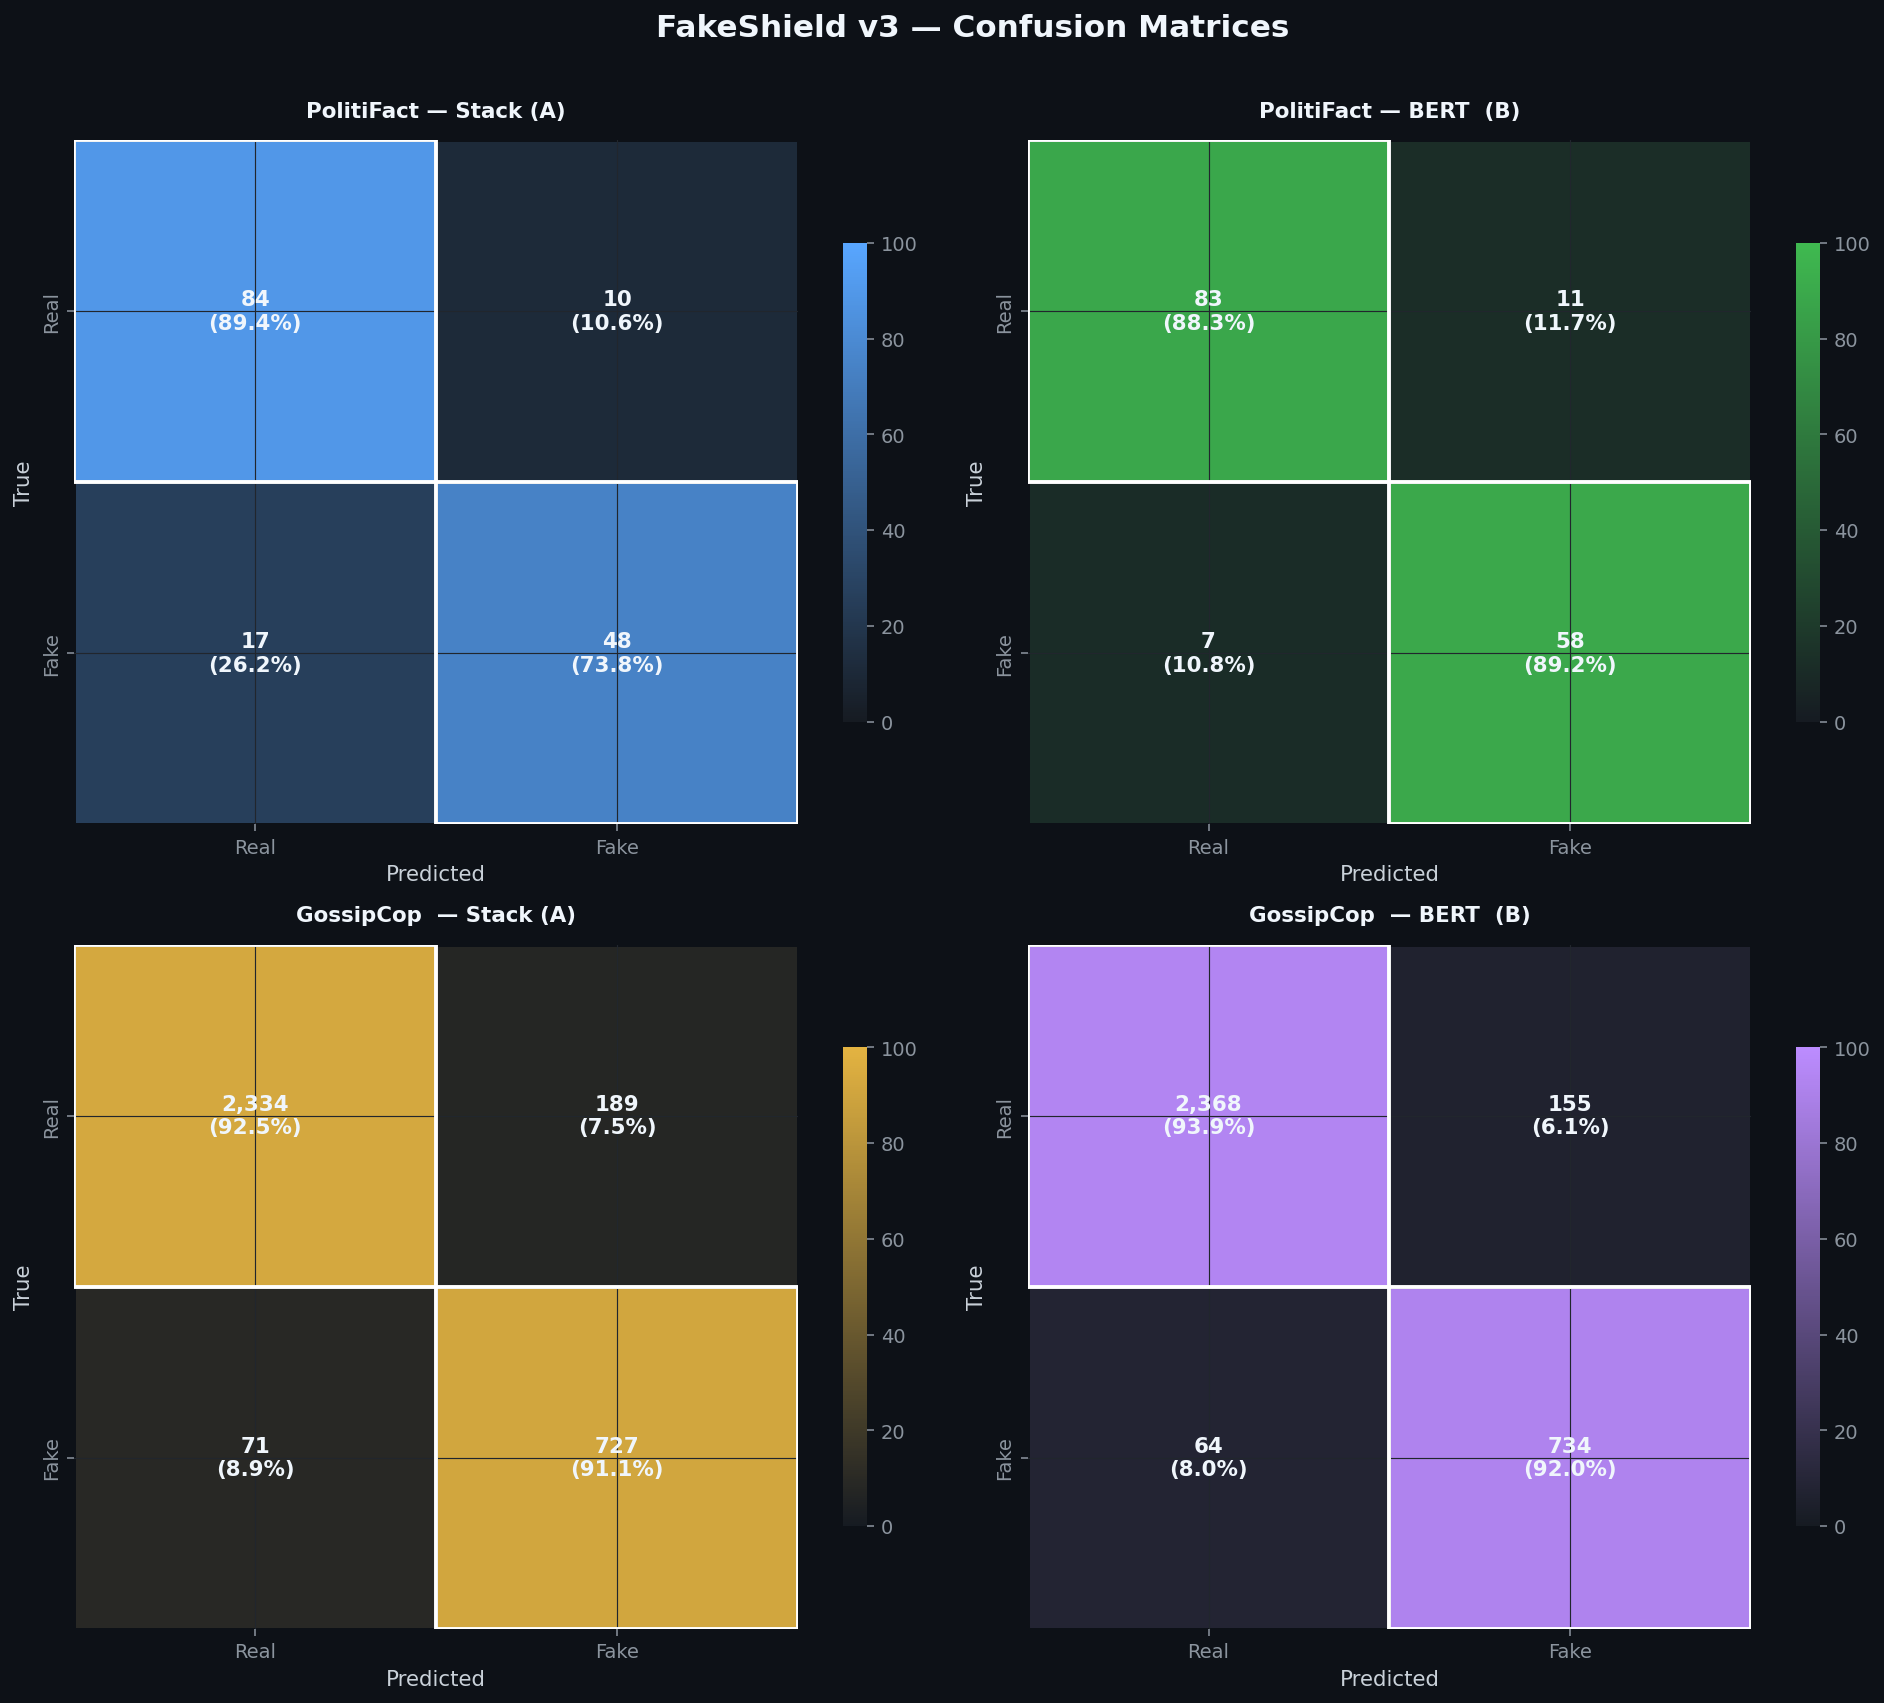

In [11]:
def plot_cm(ax, y_true, y_pred, title, color):
    cm  = confusion_matrix(y_true, y_pred)
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{cm[i,j]:,}\n({pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
    cmap  = LinearSegmentedColormap.from_list('x', ['#161B22', color])
    sns.heatmap(pct, annot=annot, fmt='', cmap=cmap, linewidths=1.5,
                linecolor='#0D1117', xticklabels=LABELS, yticklabels=LABELS,
                ax=ax, vmin=0, vmax=100,
                annot_kws={'size':11,'weight':'bold','color':'#F0F6FC'},
                cbar_kws={'shrink':0.7})
    ax.set_title(title, pad=12, fontsize=11, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    for i in range(2):
        ax.add_patch(plt.Rectangle((i,i),1,1,fill=False,edgecolor='white',lw=2,zorder=5))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('FakeShield v3 — Confusion Matrices', fontsize=16,
             fontweight='bold', color='#F0F6FC', y=1.01)

plot_cm(axes[0,0], y_pf_te, pf_stack['pred'], 'PolitiFact — Stack (A)', PALETTE['pf_stack'])
plot_cm(axes[0,1], y_pf_te, pf_bert['pred'],  'PolitiFact — BERT  (B)', PALETTE['pf_bert'])
plot_cm(axes[1,0], y_gc_te, gc_stack['pred'], 'GossipCop  — Stack (A)', PALETTE['gc_stack'])
plot_cm(axes[1,1], y_gc_te, gc_bert['pred'],  'GossipCop  — BERT  (B)', PALETTE['gc_bert'])

plt.tight_layout()
plt.savefig('fig_confusion.png', bbox_inches='tight')
plt.show()


## 8.2 — ROC & Precision-Recall Curves

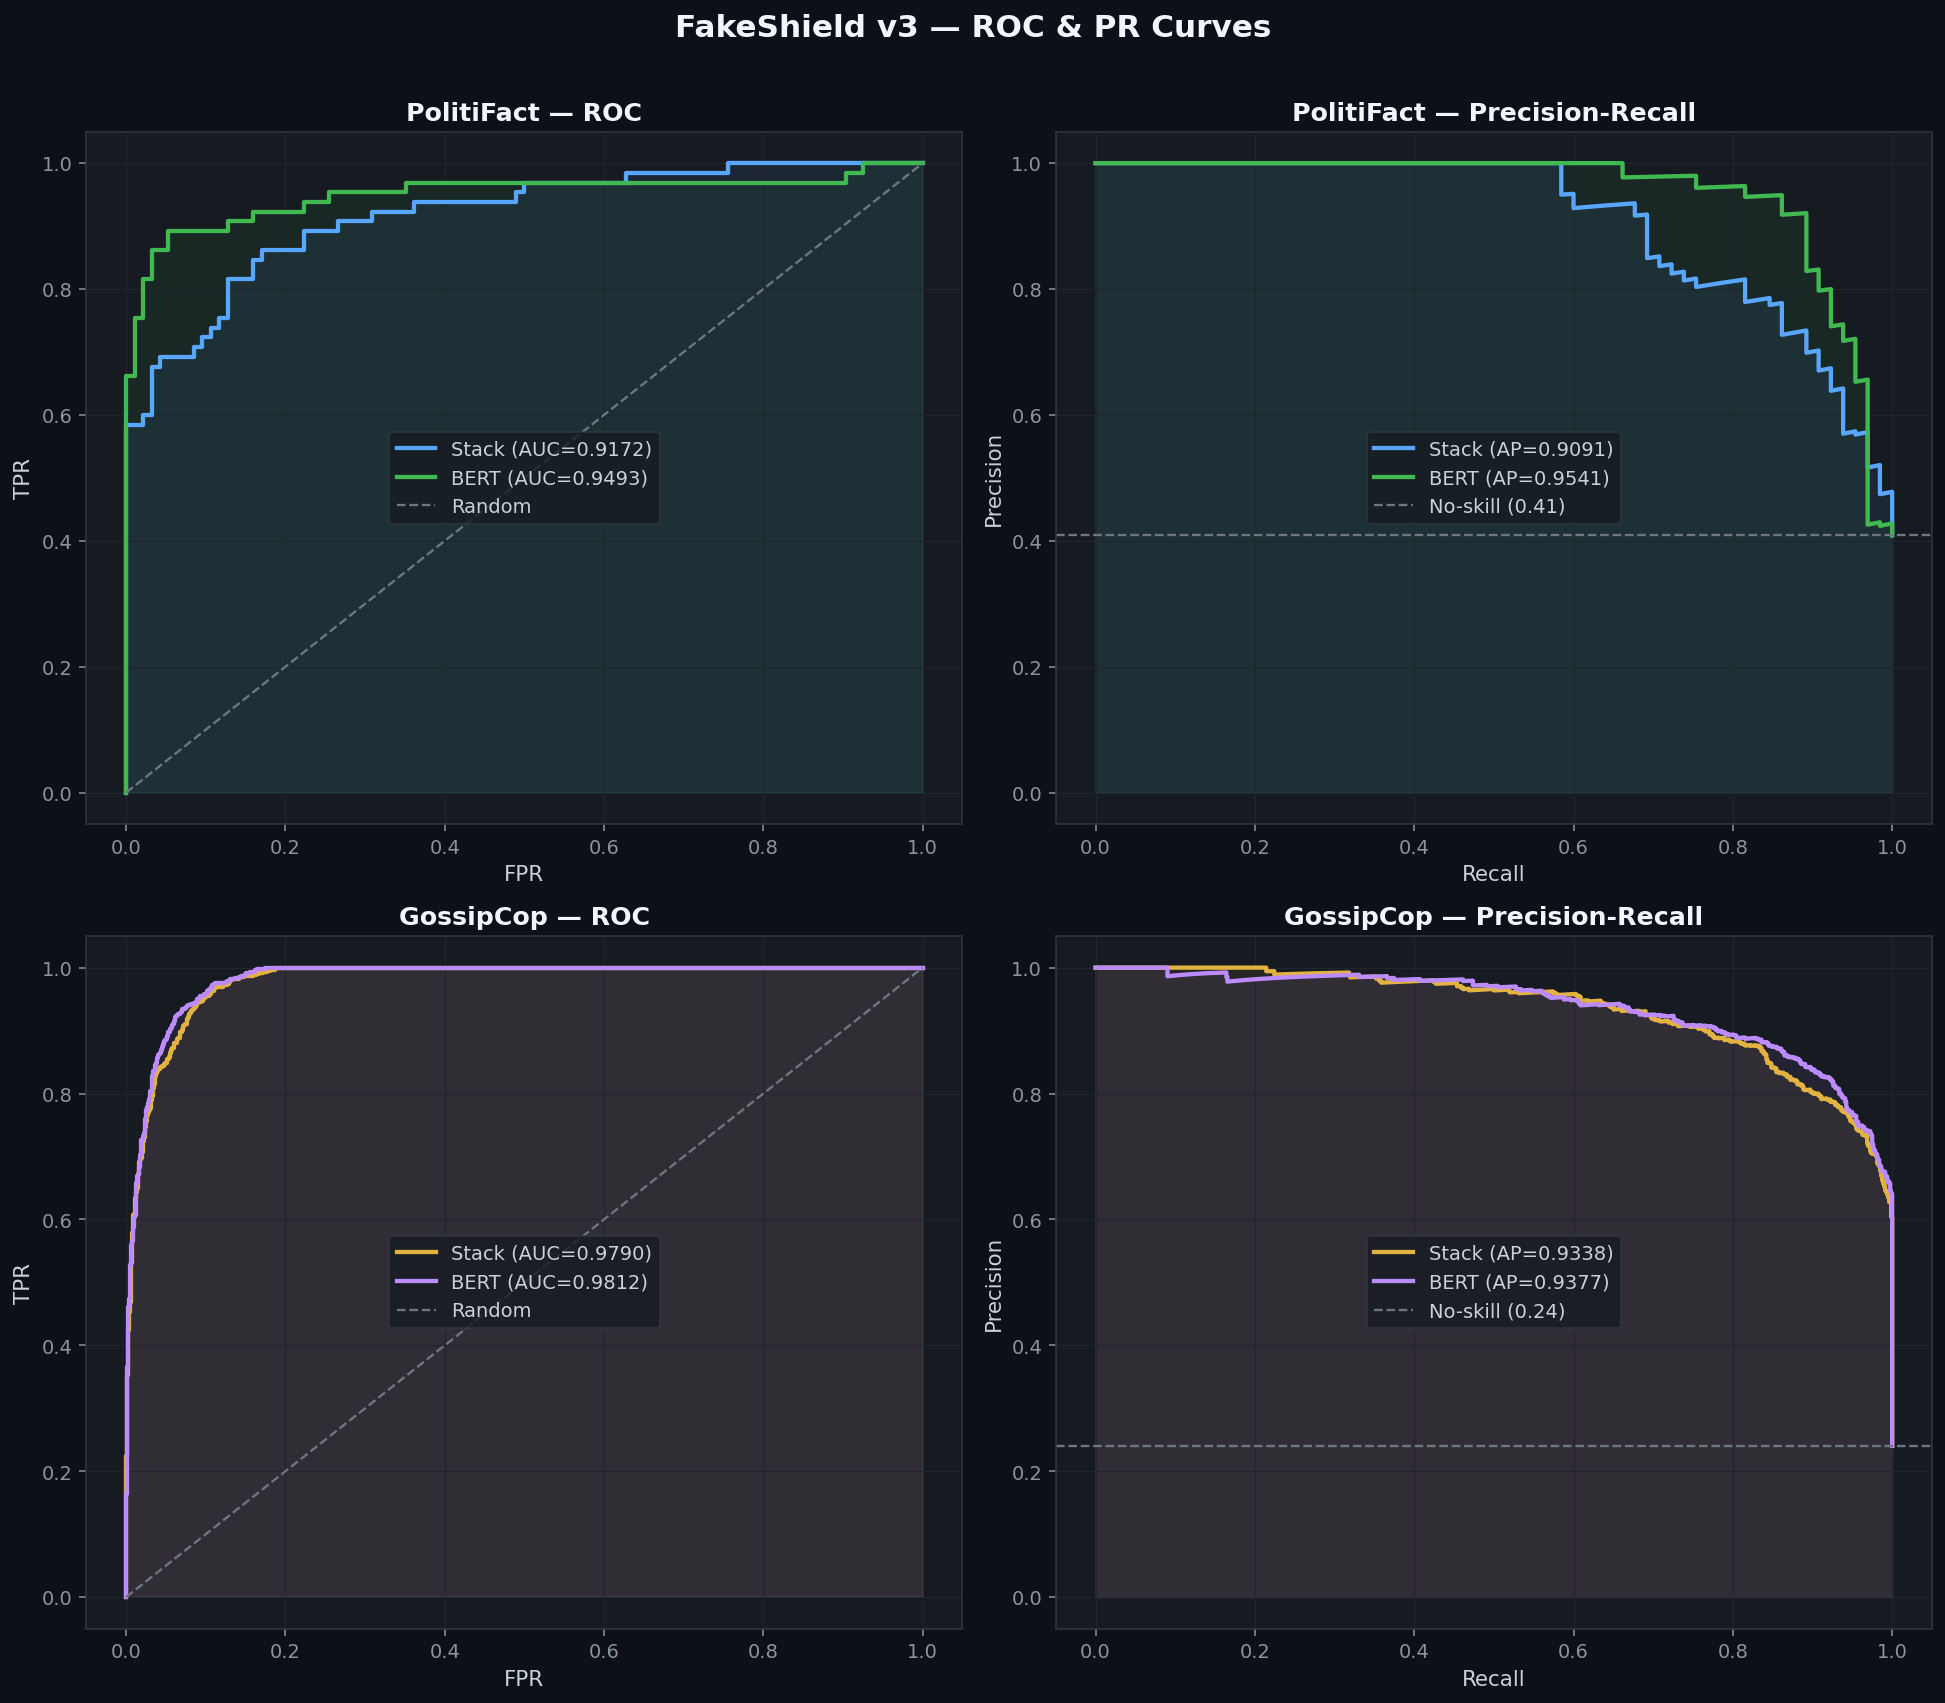

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    'FakeShield v3 — ROC & PR Curves',
    fontsize=16,
    fontweight='bold',
    color='#F0F6FC',
    y=1.01
)

for row, (y_te, s_r, b_r, domain, short) in enumerate([
    (y_pf_te, pf_stack, pf_bert, 'PolitiFact', 'pf'),
    (y_gc_te, gc_stack, gc_bert, 'GossipCop', 'gc'),
]):
    s_col = PALETTE[f'{short}_stack']
    b_col = PALETTE[f'{short}_bert']

    # ROC
    ax = axes[row, 0]
    for probs, color, label in [
        (s_r['test_prob'], s_col, 'Stack'),
        (b_r['test_prob'], b_col, 'BERT'),
    ]:
        fpr, tpr, _ = roc_curve(y_te, probs)
        auc_val = auc(fpr, tpr)
        ax.fill_between(fpr, tpr, alpha=0.08, color=color)
        ax.plot(fpr, tpr, color=color, lw=2.2, label=f'{label} (AUC={auc_val:.4f})')

    ax.plot([0, 1], [0, 1], '--', color=PALETTE['chance'], lw=1.2, label='Random')
    ax.set_title(f'{domain} — ROC', fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend()

    # PR
    ax = axes[row, 1]
    baseline = y_te.mean()

    for probs, color, label in [
        (s_r['test_prob'], s_col, 'Stack'),
        (b_r['test_prob'], b_col, 'BERT'),
    ]:
        prec, rec, _ = precision_recall_curve(y_te, probs)
        ap = average_precision_score(y_te, probs)
        ax.fill_between(rec, prec, alpha=0.08, color=color)
        ax.plot(rec, prec, color=color, lw=2.2, label=f'{label} (AP={ap:.4f})')

    ax.axhline(
        baseline,
        color=PALETTE['chance'],
        lw=1.2,
        ls='--',
        label=f'No-skill ({baseline:.2f})'
    )
    ax.set_title(f'{domain} — Precision-Recall', fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()

plt.tight_layout()
plt.savefig('fig_roc_pr.png', bbox_inches='tight')
plt.show()

## 8.3 — Threshold Sensitivity Analysis

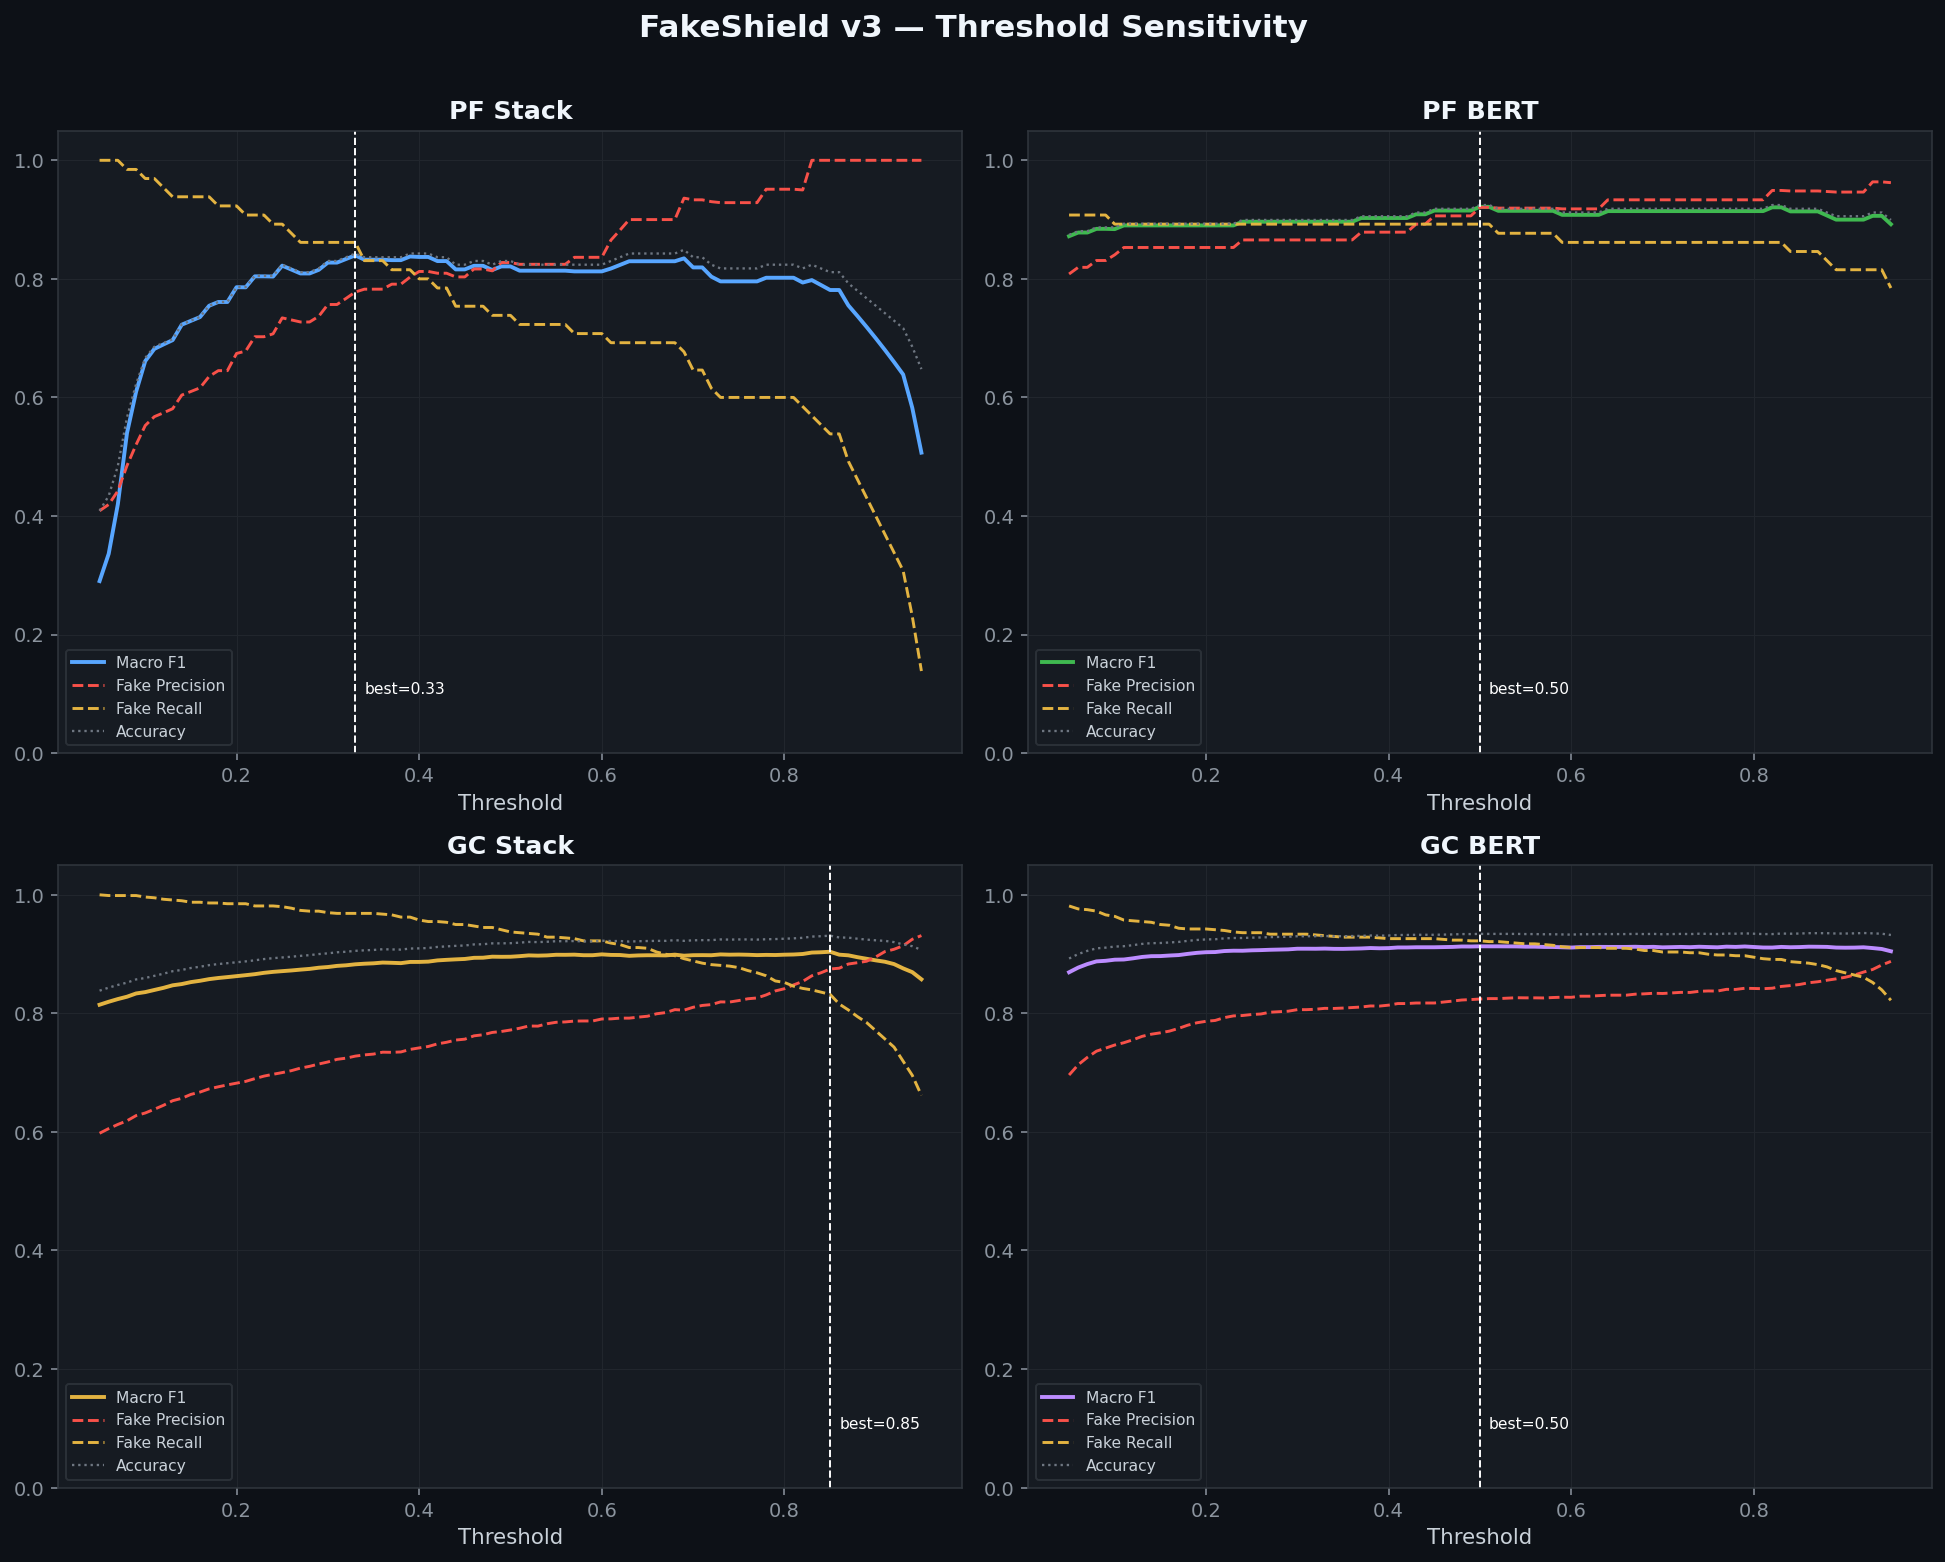

In [14]:
def plot_threshold_sweep(ax, y_true, probs, color, title):
    thresholds = np.arange(0.05, 0.96, 0.01)
    f1s, precs, recs, accs = [], [], [], []
    for t in thresholds:
        p = (probs >= t).astype(int)
        f1s.append(f1_score(y_true, p, average='macro', zero_division=0))
        precs.append(precision_score(y_true, p, pos_label=1, zero_division=0))
        recs.append(recall_score(y_true, p, pos_label=1, zero_division=0))
        accs.append(accuracy_score(y_true, p))
    best_t = thresholds[np.argmax(f1s)]
    ax.plot(thresholds, f1s,   color=color,          lw=2,   label='Macro F1')
    ax.plot(thresholds, precs, color=PALETTE['fake'], lw=1.5, ls='--', label='Fake Precision')
    ax.plot(thresholds, recs,  color='#E3B341',       lw=1.5, ls='--', label='Fake Recall')
    ax.plot(thresholds, accs,  color=PALETTE['chance'],lw=1.2,ls=':',  label='Accuracy')
    ax.axvline(best_t, color='white', lw=1, ls='--')
    ax.text(best_t+0.01, 0.1, f'best={best_t:.2f}', fontsize=8, color='white')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Threshold')
    ax.set_ylim([0, 1.05]); ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('FakeShield v3 — Threshold Sensitivity', fontsize=16,
             fontweight='bold', color='#F0F6FC', y=1.01)

plot_threshold_sweep(axes[0,0], y_pf_te, pf_stack['test_prob'], PALETTE['pf_stack'], 'PF Stack')
plot_threshold_sweep(axes[0,1], y_pf_te, pf_bert['test_prob'],  PALETTE['pf_bert'],  'PF BERT')
plot_threshold_sweep(axes[1,0], y_gc_te, gc_stack['test_prob'], PALETTE['gc_stack'], 'GC Stack')
plot_threshold_sweep(axes[1,1], y_gc_te, gc_bert['test_prob'],  PALETTE['gc_bert'],  'GC BERT')

plt.tight_layout()
plt.savefig('fig_threshold.png', bbox_inches='tight')
plt.show()


## 8.4 — Full Metrics Heatmap

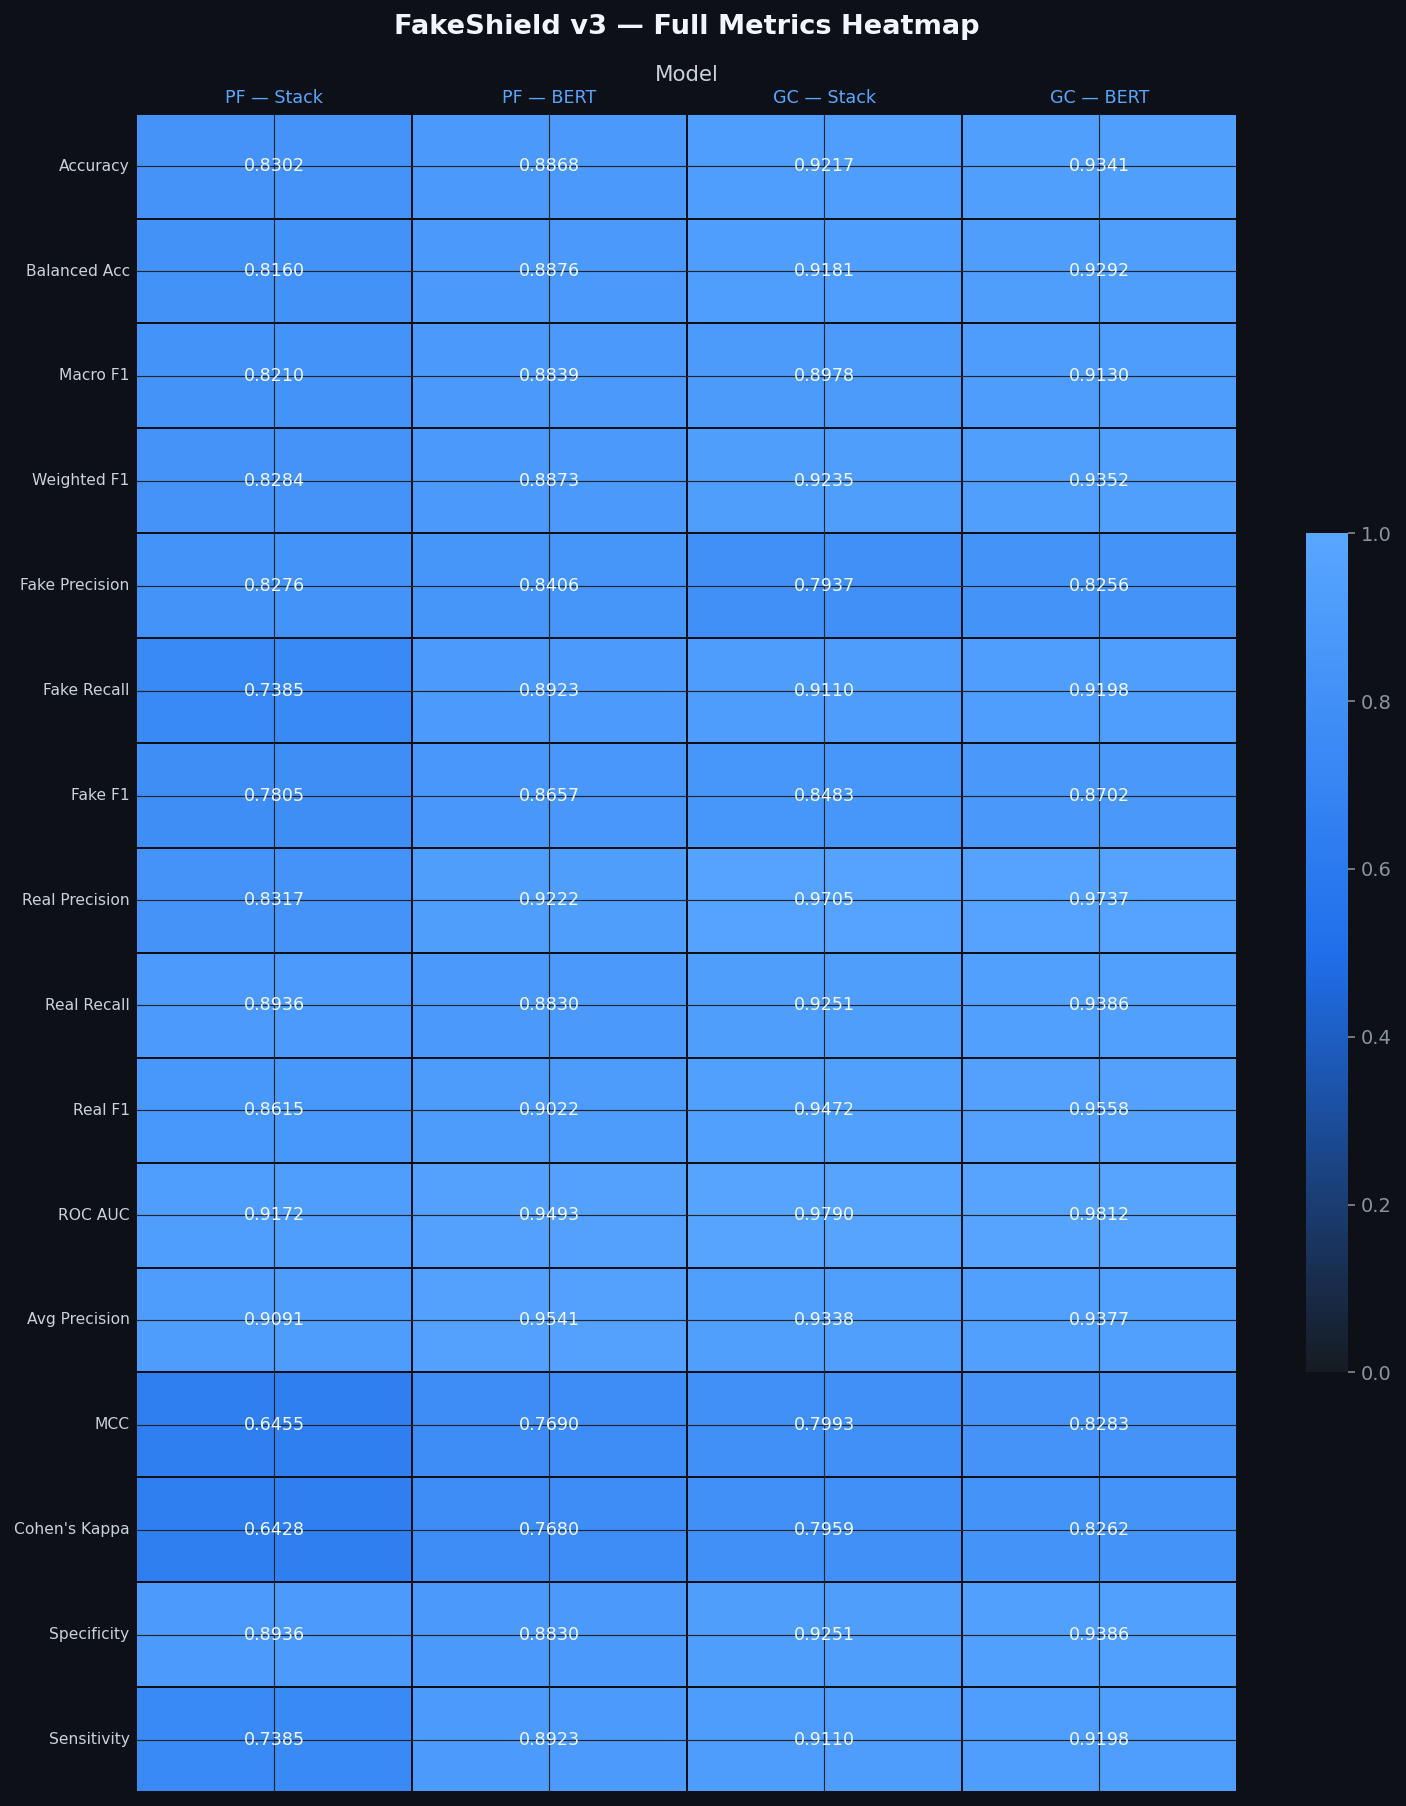

In [15]:
full_df = pd.DataFrame(all_results).set_index('Model')
plot_keys = [
    'Accuracy','Balanced Acc','Macro F1','Weighted F1',
    'Fake Precision','Fake Recall','Fake F1',
    'Real Precision','Real Recall','Real F1',
    'ROC AUC','Avg Precision','MCC',"Cohen's Kappa",
    'Specificity','Sensitivity'
]
numeric_df = full_df[plot_keys].astype(float)

fig, ax = plt.subplots(figsize=(11, 13))
cmap = LinearSegmentedColormap.from_list('perf', ['#161B22','#1F6FEB','#58A6FF'])
sns.heatmap(numeric_df.T, annot=True, fmt='.4f', cmap=cmap,
            linewidths=0.8, linecolor='#0D1117', vmin=0, vmax=1, ax=ax,
            annot_kws={'size':9,'color':'#F0F6FC'},
            cbar_kws={'shrink':0.5})
ax.set_title('FakeShield v3 — Full Metrics Heatmap', fontsize=14,
             fontweight='bold', color='#F0F6FC', pad=16)
ax.tick_params(axis='x', colors='#58A6FF', labelsize=9, length=0)
ax.tick_params(axis='y', colors='#C9D1D9', labelsize=8, length=0)
ax.xaxis.set_ticks_position('top'); ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.savefig('fig_heatmap.png', bbox_inches='tight')
plt.show()


## 8.5 — BERT Training Curves

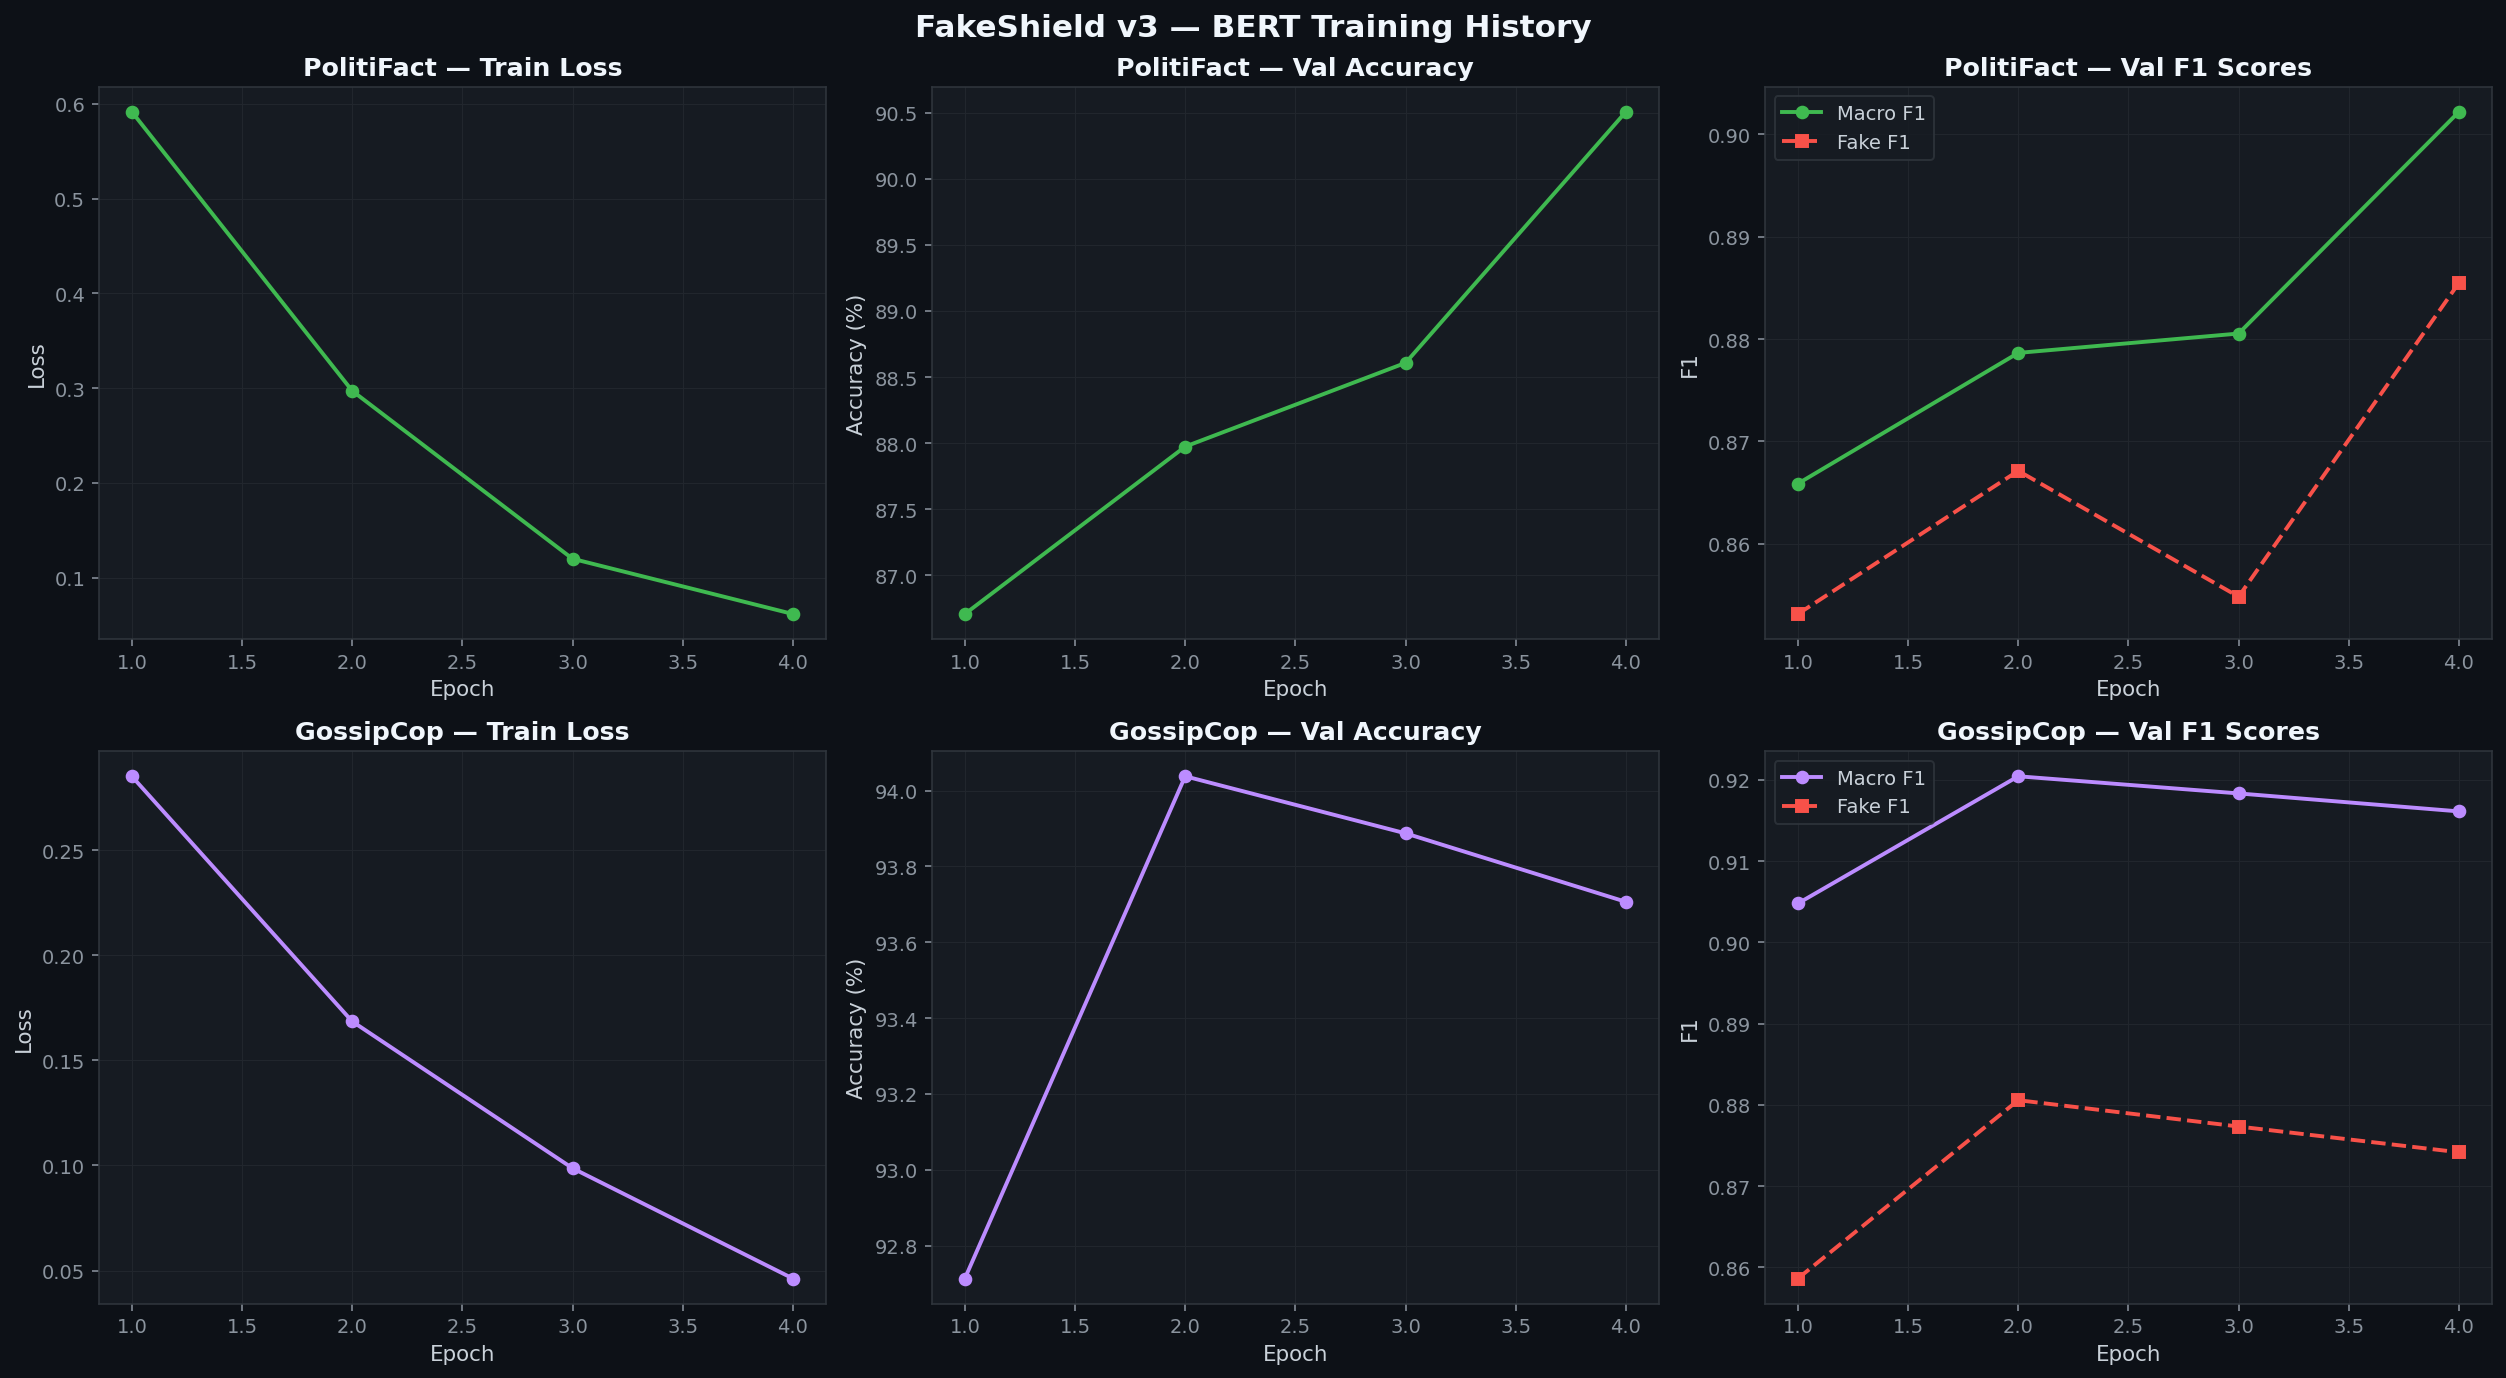

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('FakeShield v3 — BERT Training History', fontsize=16,
             fontweight='bold', color='#F0F6FC')

for row, (bert_res, color, domain) in enumerate([
    (pf_bert, PALETTE['pf_bert'],  'PolitiFact'),
    (gc_bert, PALETTE['gc_bert'],  'GossipCop'),
]):
    hist = pd.DataFrame(bert_res['history'])
    epochs = hist['epoch'].values

    axes[row,0].plot(epochs, hist['train_loss'],  color=color, lw=2, marker='o', ms=6)
    axes[row,0].set_title(f'{domain} — Train Loss', fontweight='bold')
    axes[row,0].set_xlabel('Epoch'); axes[row,0].set_ylabel('Loss')

    axes[row,1].plot(epochs, hist['val_acc']*100, color=color, lw=2, marker='o', ms=6)
    axes[row,1].set_title(f'{domain} — Val Accuracy', fontweight='bold')
    axes[row,1].set_xlabel('Epoch'); axes[row,1].set_ylabel('Accuracy (%)')

    axes[row,2].plot(epochs, hist['val_f1'],      color=color, lw=2, marker='o', ms=6, label='Macro F1')
    axes[row,2].plot(epochs, hist['val_fake_f1'], color=PALETTE['fake'], lw=2, marker='s', ms=6, ls='--', label='Fake F1')
    axes[row,2].set_title(f'{domain} — Val F1 Scores', fontweight='bold')
    axes[row,2].set_xlabel('Epoch'); axes[row,2].set_ylabel('F1'); axes[row,2].legend()

plt.tight_layout()
plt.savefig('fig_training_curves.png', bbox_inches='tight')
plt.show()


## 8.6 — Master Dashboard

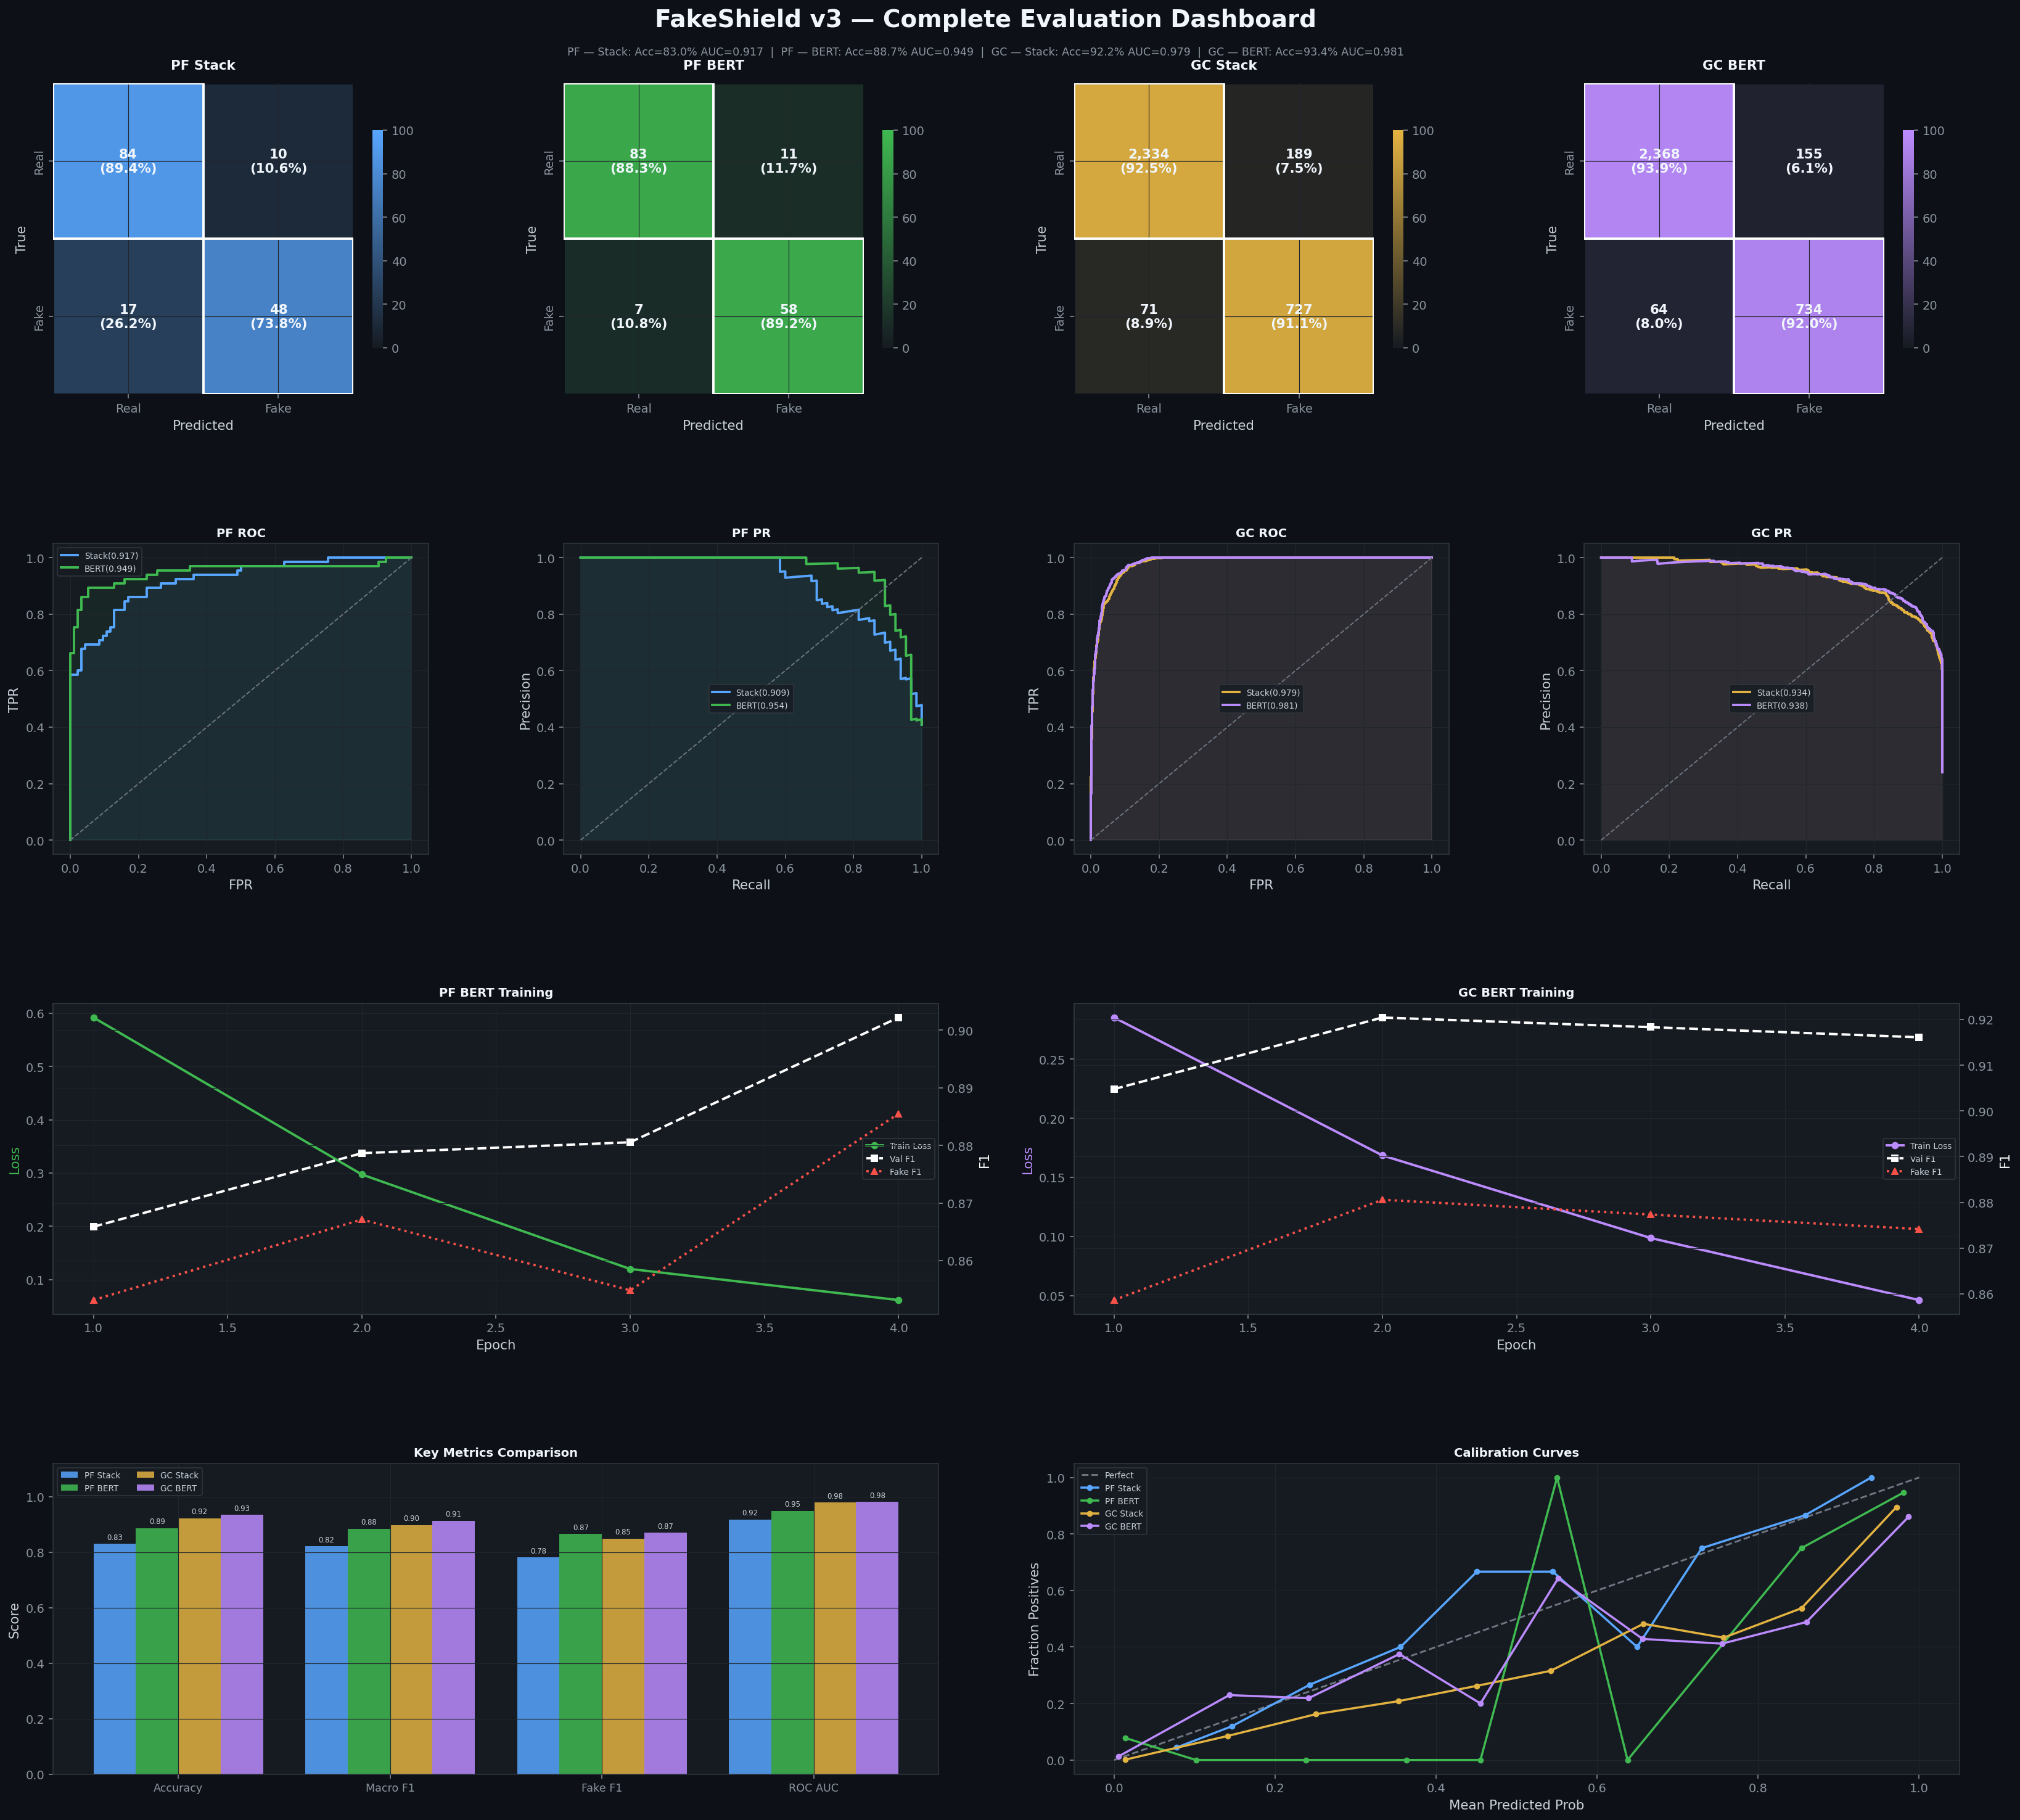

Dashboard saved.


In [17]:
fig = plt.figure(figsize=(24, 22))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.48, wspace=0.36,
                       top=0.93, bottom=0.04, left=0.05, right=0.97)

fig.text(0.5, 0.96, 'FakeShield v3 — Complete Evaluation Dashboard',
         ha='center', fontsize=20, fontweight='bold', color='#F0F6FC')

subtitle_parts = []
for r in all_results:
    subtitle_parts.append(f"{r['Model']}: Acc={r['Accuracy']*100:.1f}% AUC={r['ROC AUC']:.3f}")
fig.text(0.5, 0.945, '  |  '.join(subtitle_parts),
         ha='center', fontsize=9, color='#8B949E')

# Row 0: Confusion matrices
for i, (y_te, res, title, color) in enumerate([
    (y_pf_te, pf_stack, 'PF Stack', PALETTE['pf_stack']),
    (y_pf_te, pf_bert,  'PF BERT',  PALETTE['pf_bert']),
    (y_gc_te, gc_stack, 'GC Stack', PALETTE['gc_stack']),
    (y_gc_te, gc_bert,  'GC BERT',  PALETTE['gc_bert']),
]):
    plot_cm(fig.add_subplot(gs[0, i]), y_te, res['pred'], title, color)

# Row 1: ROC + PR
for col, (curve_fn, xs_lbl, ys_lbl, title_suffix) in enumerate([
    (roc_curve, 'FPR', 'TPR', 'ROC'),
    (precision_recall_curve, 'Recall', 'Precision', 'PR'),
]):
    for (y_te, s_r, b_r, domain, s_col, b_col) in [
        (y_pf_te, pf_stack, pf_bert, 'PF', PALETTE['pf_stack'], PALETTE['pf_bert']),
        (y_gc_te, gc_stack, gc_bert, 'GC', PALETTE['gc_stack'], PALETTE['gc_bert']),
    ]:
        ax = fig.add_subplot(gs[1, col + (0 if domain=='PF' else 2)])
        for probs, color, label in [(s_r['test_prob'], s_col, 'Stack'), (b_r['test_prob'], b_col, 'BERT')]:
            if title_suffix == 'ROC':
                fpr, tpr, _ = roc_curve(y_te, probs)
                score = auc(fpr, tpr)
                ax.fill_between(fpr, tpr, alpha=0.07, color=color)
                ax.plot(fpr, tpr, color=color, lw=2, label=f'{label}({score:.3f})')
            else:
                prec, rec, _ = precision_recall_curve(y_te, probs)
                score = average_precision_score(y_te, probs)
                ax.fill_between(rec, prec, alpha=0.07, color=color)
                ax.plot(rec, prec, color=color, lw=2, label=f'{label}({score:.3f})')
        ax.plot([0,1],[0,1],'--',color=PALETTE['chance'],lw=1)
        ax.set_title(f'{domain} {title_suffix}', fontweight='bold', fontsize=10)
        ax.set_xlabel(xs_lbl); ax.set_ylabel(ys_lbl); ax.legend(fontsize=7)

# Row 2: Training curves (loss + F1)
for col, (res, color, domain) in enumerate([
    (pf_bert, PALETTE['pf_bert'], 'PF BERT'),
    (gc_bert, PALETTE['gc_bert'], 'GC BERT'),
]):
    hist = pd.DataFrame(res['history'])
    ax = fig.add_subplot(gs[2, col*2:col*2+2])
    ax2 = ax.twinx()
    ax.plot(hist['epoch'], hist['train_loss'], color=color, lw=2, marker='o', ms=5, label='Train Loss')
    ax2.plot(hist['epoch'], hist['val_f1'], color='white', lw=2, marker='s', ms=5, ls='--', label='Val F1')
    ax2.plot(hist['epoch'], hist['val_fake_f1'], color=PALETTE['fake'], lw=2, marker='^', ms=5, ls=':', label='Fake F1')
    ax.set_title(f'{domain} Training', fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color=color)
    ax2.set_ylabel('F1', color='white')
    lines1, lbl1 = ax.get_legend_handles_labels()
    lines2, lbl2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, lbl1+lbl2, fontsize=7, loc='center right')

# Row 3: Key metrics bar chart + calibration
ax_bar = fig.add_subplot(gs[3, :2])
key_metrics = ['Accuracy','Macro F1','Fake F1','ROC AUC']
x = np.arange(len(key_metrics))
width = 0.2
colors_list = [PALETTE['pf_stack'], PALETTE['pf_bert'], PALETTE['gc_stack'], PALETTE['gc_bert']]
labels_list  = ['PF Stack','PF BERT','GC Stack','GC BERT']
for i, (r, c, lbl) in enumerate(zip(all_results, colors_list, labels_list)):
    vals = [r[m] for m in key_metrics]
    ax_bar.bar(x + i*width, vals, width, label=lbl, color=c, alpha=0.85)
ax_bar.set_xticks(x + width*1.5); ax_bar.set_xticklabels(key_metrics, fontsize=9)
ax_bar.set_ylim(0, 1.12); ax_bar.set_ylabel('Score'); ax_bar.legend(fontsize=7, ncol=2)
ax_bar.set_title('Key Metrics Comparison', fontweight='bold', fontsize=10)
for rect in ax_bar.patches:
    h = rect.get_height()
    if h > 0.01:
        ax_bar.text(rect.get_x()+rect.get_width()/2, h+0.01, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=6, color='#C9D1D9')

# Calibration
ax_cal = fig.add_subplot(gs[3, 2:])
ax_cal.plot([0,1],[0,1],'--',color=PALETTE['chance'],lw=1.5,label='Perfect')
for r, probs, y_te, c, lbl in [
    (None, pf_stack['test_prob'], y_pf_te, PALETTE['pf_stack'], 'PF Stack'),
    (None, pf_bert['test_prob'],  y_pf_te, PALETTE['pf_bert'],  'PF BERT'),
    (None, gc_stack['test_prob'], y_gc_te, PALETTE['gc_stack'], 'GC Stack'),
    (None, gc_bert['test_prob'],  y_gc_te, PALETTE['gc_bert'],  'GC BERT'),
]:
    fp_, mp_ = calibration_curve(y_te, probs, n_bins=10)
    ax_cal.plot(mp_, fp_, 'o-', color=c, lw=1.8, ms=4, label=lbl)
ax_cal.set_title('Calibration Curves', fontweight='bold', fontsize=10)
ax_cal.set_xlabel('Mean Predicted Prob'); ax_cal.set_ylabel('Fraction Positives')
ax_cal.legend(fontsize=7)

plt.savefig('fig_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved.')


---
# 9. Save All Models & Artifacts

In [18]:
os.makedirs('models/politifact', exist_ok=True)
os.makedirs('models/gossipcop',  exist_ok=True)

def save_domain(domain: str, stack: dict, bert: dict, y_tr, X_tr):
    base = f'models/{domain}'

    # Stack artifacts
    joblib.dump(stack['word_tv'],  f'{base}/word_tfidf.pkl')
    joblib.dump(stack['char_tv'],  f'{base}/char_tfidf.pkl')
    joblib.dump(stack['scaler'],   f'{base}/meta_scaler.pkl')
    joblib.dump(stack['lr'],       f'{base}/model_lr.pkl')
    joblib.dump(stack['rf'],       f'{base}/model_rf.pkl')
    joblib.dump(stack['svm'],      f'{base}/model_svm.pkl')
    joblib.dump(stack['meta_lr'],  f'{base}/model_meta.pkl')

    # BERT
    bert['model'].save_pretrained(f'{base}/bert_finetuned')
    tokenizer.save_pretrained(f'{base}/bert_finetuned')

    # Thresholds + config
    joblib.dump({
        'thresh_stack' : stack['thresh'],
        'thresh_bert'  : bert['thresh'],
        'bert_val_f1'  : bert['val_f1'],
        'n_train'      : len(y_tr),
        'n_fake_train' : int(y_tr.sum()),
        'domain'       : domain,
    }, f'{base}/config.pkl')

    print(f'  ✅ {domain} saved to {base}/')


save_domain('politifact', pf_stack, pf_bert, y_pf_tr, X_pf_tr)
save_domain('gossipcop',  gc_stack, gc_bert, y_gc_tr, X_gc_tr)

# Global metadata
meta = {
    'version'      : '3.0',
    'bert_model'   : CFG.bert_model,
    'max_len'      : CFG.max_len,
    'seed'         : SEED,
    'improvements' : [
        'Doubled-title de-duplication',
        'Boilerplate regex removal',
        'Title prepended to text',
        'Word(1,3) + Char(3,5) TF-IDF FeatureUnion',
        'Meta-features: text_len, title_len, tweet_count, is_stub',
        'LR saga solver for high-dim sparse features',
        'Domain-specialised separate training',
        'Recall-weighted threshold (60% fake-recall weight)',
    ],
    'results' : {r['Model']: {
        'accuracy': round(r['Accuracy']*100, 2),
        'macro_f1': round(r['Macro F1']*100, 2),
        'roc_auc' : round(r['ROC AUC'], 4),
        'mcc'     : round(r['MCC'], 4),
    } for r in all_results},
}
with open('models/metadata.json','w') as f:
    json.dump(meta, f, indent=2)

print('\nMetadata:')
print(json.dumps(meta['results'], indent=2))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ politifact saved to models/politifact/


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ gossipcop saved to models/gossipcop/

Metadata:
{
  "PF \u2014 Stack": {
    "accuracy": 83.02,
    "macro_f1": 82.1,
    "roc_auc": 0.9172,
    "mcc": 0.6455
  },
  "PF \u2014 BERT": {
    "accuracy": 88.68,
    "macro_f1": 88.39,
    "roc_auc": 0.9493,
    "mcc": 0.769
  },
  "GC \u2014 Stack": {
    "accuracy": 92.17,
    "macro_f1": 89.78,
    "roc_auc": 0.979,
    "mcc": 0.7993
  },
  "GC \u2014 BERT": {
    "accuracy": 93.41,
    "macro_f1": 91.3,
    "roc_auc": 0.9812,
    "mcc": 0.8283
  }
}


---
# 10. ZIP Export

In [19]:
ALL_PLOTS = [
    'fig_confusion.png', 'fig_roc_pr.png', 'fig_threshold.png',
    'fig_heatmap.png', 'fig_training_curves.png', 'fig_dashboard.png',
    'results_full.csv',
]

with zipfile.ZipFile('fakeshield_v3.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk('models'):
        for f in files:
            fp = os.path.join(root, f)
            zf.write(fp); print(f'  + {fp}')
    for f in ALL_PLOTS:
        if os.path.exists(f):
            zf.write(f); print(f'  + {f}')

import os
size_mb = os.path.getsize('fakeshield_v3.zip') / 1e6
print(f'\n✅  fakeshield_v3.zip  ({size_mb:.1f} MB)')


  + models/metadata.json
  + models/gossipcop/config.pkl
  + models/gossipcop/model_svm.pkl
  + models/gossipcop/meta_scaler.pkl
  + models/gossipcop/char_tfidf.pkl
  + models/gossipcop/model_meta.pkl
  + models/gossipcop/word_tfidf.pkl
  + models/gossipcop/model_rf.pkl
  + models/gossipcop/model_lr.pkl
  + models/gossipcop/bert_finetuned/model.safetensors
  + models/gossipcop/bert_finetuned/config.json
  + models/gossipcop/bert_finetuned/tokenizer_config.json
  + models/gossipcop/bert_finetuned/tokenizer.json
  + models/politifact/config.pkl
  + models/politifact/model_svm.pkl
  + models/politifact/meta_scaler.pkl
  + models/politifact/char_tfidf.pkl
  + models/politifact/model_meta.pkl
  + models/politifact/word_tfidf.pkl
  + models/politifact/model_rf.pkl
  + models/politifact/model_lr.pkl
  + models/politifact/bert_finetuned/model.safetensors
  + models/politifact/bert_finetuned/config.json
  + models/politifact/bert_finetuned/tokenizer_config.json
  + models/politifact/bert_finetu

In [ ]:
from google.colab import files
files.download('fakeshield_v3.zip')


---
# 11. Production Inference Engine

## Usage:
```python
result = predict(
    text   = "Senator claims unemployment is at a 50-year low",
    title  = "Senator claims unemployment is at a 50-year low",
    source = "politifact"
)
```
The engine applies identical preprocessing as training,
routes to the correct domain model, and returns structured output
with probability scores, thresholds, and confidence band.


In [20]:
def predict(text: str, title: str, source: str,
            return_all_probs: bool = False) -> dict:
    """
    Production inference for FakeShield v3.

    Args:
        text           : article body text
        title          : article headline
        source         : 'politifact' or 'gossipcop'
        return_all_probs: include individual base-learner probs in output

    Returns:
        dict with keys: source, path_a, path_b, ensemble
    """
    source = source.lower().strip()
    assert source in ('politifact', 'gossipcop'), \
        f"source must be 'politifact' or 'gossipcop', got '{source}'"

    # ── Preprocessing (identical to training) ────────────────────────────
    clean  = clean_text(text)
    inp    = title.lower().strip() + ' . ' + clean

    # ── Domain routing ────────────────────────────────────────────────────
    s = pf_stack if source == 'politifact' else gc_stack
    b = pf_bert  if source == 'politifact' else gc_bert

    # ── Meta features ─────────────────────────────────────────────────────
    text_len    = len(clean.split())
    title_len   = len(title.split())
    meta_row    = np.array([[
        np.log1p(text_len), float(title_len), 0.0,
        float(text_len < 20), float(text_len > 200),
        np.log1p(title_len * text_len + 1)
    ]])
    meta_scaled = s['scaler'].transform(meta_row)

    # ── Path A ────────────────────────────────────────────────────────────
    wv  = s['word_tv'].transform([inp])
    cv  = s['char_tv'].transform([inp])
    mv  = sp.csr_matrix(meta_scaled)
    fv  = sp.hstack([wv, cv, mv])

    p_lr  = s['lr'].predict_proba(fv)[0,1]
    p_rf  = s['rf'].predict_proba(fv)[0,1]
    p_svm = s['svm'].predict_proba(fv)[0,1]
    p_stk = s['meta_lr'].predict_proba([[p_lr, p_rf, p_svm]])[0,1]
    out_a = 'FAKE' if p_stk >= s['thresh'] else 'REAL'

    # ── Path B ────────────────────────────────────────────────────────────
    bm = b['model']; bm.eval()
    enc = tokenizer(inp, truncation=True, padding='max_length',
                    max_length=CFG.max_len, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        p_bert = torch.softmax(bm(**enc).logits, dim=1)[0,1].item()
    out_b = 'FAKE' if p_bert >= b['thresh'] else 'REAL'

    # ── Ensemble (average) ────────────────────────────────────────────────
    p_ens = (p_stk + p_bert) / 2.0
    thresh_ens = (s['thresh'] + b['thresh']) / 2.0
    out_ens = 'FAKE' if p_ens >= thresh_ens else 'REAL'

    confidence = abs(p_ens - thresh_ens) / max(thresh_ens, 1 - thresh_ens)
    band = ('HIGH' if confidence > 0.4 else
            'MEDIUM' if confidence > 0.2 else 'LOW')

    result = {
        'source'   : source,
        'input_len': text_len,
        'path_a'   : {
            'prob': round(p_stk, 4), 'threshold': s['thresh'],
            'prediction': out_a,
        },
        'path_b'   : {
            'prob': round(p_bert, 4), 'threshold': b['thresh'],
            'prediction': out_b,
        },
        'ensemble' : {
            'prob': round(p_ens, 4), 'threshold': round(thresh_ens, 2),
            'prediction': out_ens, 'confidence': band,
        },
    }
    if return_all_probs:
        result['base_probs'] = {'LR': round(p_lr,4), 'RF': round(p_rf,4), 'SVM': round(p_svm,4)}

    return result


# ── Batch convenience ─────────────────────────────────────────────────────
def predict_batch(records: list) -> pd.DataFrame:
    """records = list of dicts with keys: text, title, source"""
    rows = []
    for r in records:
        res = predict(r['text'], r['title'], r['source'])
        rows.append({
            'source'         : res['source'],
            'stack_pred'     : res['path_a']['prediction'],
            'stack_prob'     : res['path_a']['prob'],
            'bert_pred'      : res['path_b']['prediction'],
            'bert_prob'      : res['path_b']['prob'],
            'ensemble_pred'  : res['ensemble']['prediction'],
            'ensemble_prob'  : res['ensemble']['prob'],
            'confidence'     : res['ensemble']['confidence'],
        })
    return pd.DataFrame(rows)


# ── Demo ─────────────────────────────────────────────────────────────────
samples = [
    dict(
        title  = 'Senator claims unemployment hit a 50-year low',
        text   = 'Senator claims unemployment hit a 50-year low',
        source = 'politifact'
    ),
    dict(
        title  = 'Government confirms COVID vaccines contain microchips',
        text   = 'Government confirms COVID vaccines contain microchips to track citizens worldwide breaking news',
        source = 'politifact'
    ),
    dict(
        title  = "Taylor Swift's new album breaks streaming records",
        text   = "Taylor Swift's new album broke several streaming records this week according to Spotify's official report, surpassing previous records set by her prior releases with over 500 million streams in its first 24 hours.",
        source = 'gossipcop'
    ),
    dict(
        title  = 'Celebrity secretly married in private ceremony',
        text   = 'Celebrity secretly married in private ceremony',
        source = 'gossipcop'
    ),
]

print('\n' + '='*72)
print('  FakeShield v3 — Inference Demo')
print('='*72)
for s in samples:
    res = predict(s['text'], s['title'], s['source'], return_all_probs=True)
    print(f"\n  [{res['source'].upper()}] {s['title'][:60]}")
    print(f"  Stack  : {res['path_a']['prediction']:4s}  (p={res['path_a']['prob']:.3f}  thresh={res['path_a']['threshold']})")
    print(f"  BERT   : {res['path_b']['prediction']:4s}  (p={res['path_b']['prob']:.3f}  thresh={res['path_b']['threshold']})")
    print(f"  Ensemble: {res['ensemble']['prediction']:4s}  (p={res['ensemble']['prob']:.3f}  confidence={res['ensemble']['confidence']})")



  FakeShield v3 — Inference Demo

  [POLITIFACT] Senator claims unemployment hit a 50-year low
  Stack  : REAL  (p=0.117  thresh=0.5)
  BERT   : FAKE  (p=0.186  thresh=0.1)
  Ensemble: REAL  (p=0.151  confidence=MEDIUM)

  [POLITIFACT] Government confirms COVID vaccines contain microchips
  Stack  : REAL  (p=0.361  thresh=0.5)
  BERT   : FAKE  (p=0.950  thresh=0.1)
  Ensemble: FAKE  (p=0.655  confidence=HIGH)

  [GOSSIPCOP] Taylor Swift's new album breaks streaming records
  Stack  : REAL  (p=0.163  thresh=0.64)
  BERT   : FAKE  (p=0.856  thresh=0.53)
  Ensemble: REAL  (p=0.509  confidence=LOW)

  [GOSSIPCOP] Celebrity secretly married in private ceremony
  Stack  : FAKE  (p=0.936  thresh=0.64)
  BERT   : FAKE  (p=0.995  thresh=0.53)
  Ensemble: FAKE  (p=0.966  confidence=HIGH)


---
# 12. Load Models (Restore Session)
Run this cell to reload all saved models without retraining.


In [24]:
import os

for domain in ['politifact', 'gossipcop']:
    base = f'models/{domain}'
    print(f'\nChecking: {base}')
    if os.path.exists(base):
        print("✅ Folder exists")
        print(os.listdir(base))
    else:
        print("❌ Folder missing")


Checking: models/politifact
✅ Folder exists
['config.pkl', 'bert_finetuned', 'model_svm.pkl', 'meta_scaler.pkl', 'char_tfidf.pkl', 'model_meta.pkl', 'word_tfidf.pkl', 'model_rf.pkl', 'model_lr.pkl']

Checking: models/gossipcop
✅ Folder exists
['config.pkl', 'bert_finetuned', 'model_svm.pkl', 'meta_scaler.pkl', 'char_tfidf.pkl', 'model_meta.pkl', 'word_tfidf.pkl', 'model_rf.pkl', 'model_lr.pkl']


In [25]:
import os

required_files = [
    'config.pkl',
    'word_tfidf.pkl',
    'char_tfidf.pkl',
    'meta_scaler.pkl',
    'model_lr.pkl',
    'model_rf.pkl',
    'model_svm.pkl',
    'model_meta.pkl',
]

for domain in ['politifact', 'gossipcop']:
    base = f'models/{domain}'
    print(f'\n=== {domain.upper()} ===')

    if not os.path.exists(base):
        print("❌ Base folder missing")
        continue

    all_ok = True

    for f in required_files:
        path = os.path.join(base, f)
        if os.path.exists(path):
            print(f"✅ {f}")
        else:
            print(f"❌ {f}")
            all_ok = False

    bert_path = os.path.join(base, 'bert_finetuned')
    if os.path.exists(bert_path):
        print("✅ bert_finetuned folder")
        print("   ", os.listdir(bert_path))
    else:
        print("❌ bert_finetuned folder missing")
        all_ok = False

    if all_ok:
        print("🎉 All required files present")
    else:
        print("⚠️ Some files are missing")



=== POLITIFACT ===
✅ config.pkl
✅ word_tfidf.pkl
✅ char_tfidf.pkl
✅ meta_scaler.pkl
✅ model_lr.pkl
✅ model_rf.pkl
✅ model_svm.pkl
✅ model_meta.pkl
✅ bert_finetuned folder
    ['model.safetensors', 'config.json', 'tokenizer_config.json', 'tokenizer.json']
🎉 All required files present

=== GOSSIPCOP ===
✅ config.pkl
✅ word_tfidf.pkl
✅ char_tfidf.pkl
✅ meta_scaler.pkl
✅ model_lr.pkl
✅ model_rf.pkl
✅ model_svm.pkl
✅ model_meta.pkl
✅ bert_finetuned folder
    ['model.safetensors', 'config.json', 'tokenizer_config.json', 'tokenizer.json']
🎉 All required files present


In [27]:
def load_domain(domain: str) -> Tuple[dict, dict]:
    base = f'models/{domain}'
    cfg_ = joblib.load(f'{base}/config.pkl')

    stack = dict(
        word_tv = joblib.load(f'{base}/word_tfidf.pkl'),
        char_tv = joblib.load(f'{base}/char_tfidf.pkl'),
        scaler  = joblib.load(f'{base}/meta_scaler.pkl'),
        lr      = joblib.load(f'{base}/model_lr.pkl'),
        rf      = joblib.load(f'{base}/model_rf.pkl'),
        svm     = joblib.load(f'{base}/model_svm.pkl'),
        meta_lr = joblib.load(f'{base}/model_meta.pkl'),
        thresh  = cfg_['thresh_stack'],
    )

    bert_model_loaded = AutoModelForSequenceClassification.from_pretrained(
        f'{base}/bert_finetuned'
    )

    bert_model_loaded.eval()

    bert = dict(
        model=bert_model_loaded,
        thresh=cfg_['thresh_bert']
    )

    print(f'  ✅ {domain} loaded  (stack_thresh={stack["thresh"]}  bert_thresh={bert["thresh"]})')
    return stack, bert

In [28]:
pf_stack, pf_bert = load_domain('politifact')
gc_stack, gc_bert = load_domain('gossipcop')
print("\n✅ Both domains loaded successfully")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  ✅ politifact loaded  (stack_thresh=0.5  bert_thresh=0.1)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  ✅ gossipcop loaded  (stack_thresh=0.64  bert_thresh=0.53)

✅ Both domains loaded successfully


In [29]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [30]:
BASE_SAVE = "/content/drive/MyDrive/models"

In [31]:
import os
import joblib

pf_path = f"{BASE_SAVE}/politifact"
os.makedirs(pf_path, exist_ok=True)

# Save stacking components
joblib.dump(pf_word_tv, f"{pf_path}/word_tfidf.pkl")
joblib.dump(pf_char_tv, f"{pf_path}/char_tfidf.pkl")
joblib.dump(pf_scaler,  f"{pf_path}/meta_scaler.pkl")

joblib.dump(pf_lr,  f"{pf_path}/model_lr.pkl")
joblib.dump(pf_rf,  f"{pf_path}/model_rf.pkl")
joblib.dump(pf_svm, f"{pf_path}/model_svm.pkl")
joblib.dump(pf_meta_lr, f"{pf_path}/model_meta.pkl")

# Save config
joblib.dump({
    "thresh_stack": pf_thresh_stack,
    "thresh_bert": pf_thresh_bert
}, f"{pf_path}/config.pkl")

# Save BERT
pf_bert_model.save_pretrained(f"{pf_path}/bert_finetuned")
pf_tokenizer.save_pretrained(f"{pf_path}/bert_finetuned")

print("✅ PolitiFact saved to Drive")

NameError: name 'pf_word_tv' is not defined